# 9 - **Procesamiento del Lenguaje Natural**: Introducción a las Redes Neuronales: Pytorch y Perceptrones Multicapa (MLPs)

**Angel Navia Vázquez, Pablo Martínez Olmos, Vanessa Gómez Verdejo, Emilio Parrado Hernández**

  * 1.1 (January 2026) Revised and updated version

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />




## 1 - Las Redes Neuronales

El cerebro de los seres vivos está compuesto por infinidad de **células nerviosas interconectadas**. Cada una de estas células se denomina **neurona**. Esta estructura neuronal fue observada (y detalladamente dibujada) por primera vez por el investigador español **Santiago Ramón y Cajal, premio Nobel en Medicina (1906)**.

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/ramon_y_cajal_neuronas.png' width=600 />
</center>

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/Neuronas.jpg' width=280 />

<img src='http://www.tsc.uc3m.es/~navia/figures/Neuronas2.jpg' width=400 />
</center>




Una posible **representación simplificada** podría ser como sigue:


<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/neurona.png' width=400 />
</center>

- Las **dendritas** reciben **señales de entrada** procedentes de estímulos externos u otras neuronas. Las **sinapsis** determina la **fuerza** con la que dichos **estímulos** llegan a la neurona.

- El **cuerpo** de la célula **acumula todos los estímulos** recibidos.

- Al alcanzar un **umbral**, se dispara una **salida** a través del axón, que eventualmente alcanzará otras neuronas.



### 1.1 - El modelo artificial de McCulloch y Pitts

En 1943,  **McCulloch y Pitts** proponen un **modelo de neurona artificial simplificado**, como aproximación a la neurona real:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/neurona_artificial_v2.png' width=500 />
</center>

- $x_i$ representan los **estímulos de entrada**.

- $w_i$ representan los **pesos de las conexiones** sinápticas.

- Los **estímulos ponderados por los pesos** se combinan: $z = w_1 x_1 + w_2 x_2 + ... + w_nx_n + b$.

- Finalmente se produce una **salida de la neurona** tras atravesar una **función de activación no lineal**:  $y = \psi(z) $.

Se pueden utilizar **distintas funciones de activación**, desde la ya conocida **sigmoide** hasta una de las más populares en redes de Aprendizaje Profundo o Deep Learning conocida como "**ReLU**" (Rectified Linear Unit):

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/activaciones.png' width=800 />
</center>

### 1.2 - Los Perceptrones Multicapa (MLPs)

El primer modelo de neuronas interconectadas fue el **perceptron** de dos capas de **Frank Rosenblatt** (1958), posteriormente generalizado a **múltiples capas** en 1975. Al igual que en el cerebro, en estos modelos las neuronas artificiales se **interconectan entre ellas en capas**, de forma que la señal se propaga de la entrada hacia la salida (izquierda a derecha):  

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/MLP.png' width=500 />
</center>

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/Salida_MLP.png' width=500 />
</center>

Veamos en primer lugar cómo medir el ajuste de la red mediante la **función de coste**. Posteriormente necesitaremos métodos para adaptar los valores de los **pesos**, de forma que se minimice dicha función de coste. Este procedimiento se denomina **entrenamiento**.

### 1.3 - El algoritmo "Error Back-Propagation".

En la **salida del MLP** es posible **cuantificar las prestaciones** mediante una **función de coste** (recuerde que las salidas $\hat{y}^{(n)}$ se obtienen en función de los pesos $W$ de la red):  

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/Coste_MLP.png' width=500 />
</center>

El **coste** $\cal{L}()$ mide la **discrepancia** entre las **salidas verdaderas** $y^{(n)}$ y las **salidas estimadas** por la red $\hat{y}^{(n)}$. Por ejemplo, en el caso de coste cuadrático, $\cal{L}(\hat{y}^{(n)}, y^{(n)}) = (\hat{y}^{(n)}-y^{(n)})^2$

Los pesos óptimos se obtendrán resolviendo un **problema de optimización**, que debe encontrar el valor óptimo de los pesos tal que el **coste global sea mínimo**.

En general, la **función de coste de los MLPs con respecto a los pesos** suele tener una **forma complicada** (**no convexa**), con **múltiples mínimos locales**, lo que dificulta encontrar la solución óptima. El procedimiento más habitual consiste en **descender por la superficie de error**, hasta alcanzar el **mínimo local más próximo**.

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/MLP_cost1y2.png' width=800 />
</center>

El procedimiento de **entrenamiento por descenso según gradiente** comprendería los siguientes pasos:

- Se **inician los pesos aleatoriamente** $W_0$.

- Se calcula el **gradiente respecto a los pesos** $\frac{\partial J}{\partial W}$

- Se **actualizan los pesos** ligeramente ($\mu$) en la **dirección de máximo descenso** (opuesto al gradiente): $ W_{n+1} \leftarrow W_{n} - \mu \frac{\partial J}{\partial W} $

- Con los nuevos pesos $W_{n+1}$ se **recalculan las nuevas salidas de la red y la función de coste** y se **repite el procedimiento** hasta que se cumple un **criterio de parada**.



Calcular los valores de $\frac{\partial J}{\partial W}$ para pesos en **capas ocultas** requiere la aplicación de la regla de la cadena, que es poco eficiente (recordemos la expresión de las salidas en función de las entradas:)

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/Salida_MLP.png' width=500 />
</center>




En 1986, **David Rumelhart, Geoffrey  Hinton & Ronald  Williams** publicaron un [**artículo en la revista Nature**](http://www.cs.utoronto.ca/~hinton/absps/naturebp.pdf) titulado "**Learning Representations by back-propagating errors**", en el que se describe un procedimiento eficiente para el entrenamiento de los pesos en neuronas de capas ocultas: el **algoritmo de retro-propagación de errores o Error Back-Propagation (EBP)**:


<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/EBP.png' width=800 />
</center>

Veamos cómo implementar estos modelos en Python.

## 2 - Introducción a Pytorch

[**Pytorch**](https://pytorch.org/) es un entorno de código abierto para **aprendizaje automático** que acelera el camino desde la creación de prototipos de investigación hasta la implementación de producción. En particular, nos proporciona **mecanismos de** [**diferenciación automática**](https://proceedings.neurips.cc/paper/2018/file/770f8e448d07586afbf77bb59f698587-Paper.pdf) para optimización numérica que nos permitirán **entrenar redes neuronales de forma sencilla y eficiente**.

Aprenderemos aquí a utilizar **Pytorch** para entrenar una **Regresión Logística** y una red neuronal de tipo **MLP** en un problema de clasificación binaria. **Pytorch se encargará de aplicar el algoritmo de retro-propagación de errores a la red que definamos, con la función de coste que elijamos**. Podemos entender más de su funcionamiento interno en este [**artículo**](https://medium.com/@noel.B/breaking-down-backpropagation-in-pytorch-3762ea107d3a).


=================================================================

**Nota:** A fin de ejecutar los modelos con mayor velocidad, conviene **activar la GPU en Google Colab**:

- **Entorno de ejecución** > Cambiar tipo de entorno de ejecución (``Change runtime type``).
- En **Acelerador de hardware** (``Hardware accelerator``), selecciona **``GPU T4``** (NVIDIA Tesla T4, 16 GB de VRAM) y guardar configuración.

=================================================================

In [1]:
# Ejecutamos este código para preparar el contexto.
from IPython.core.display import Image, display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import cm

# Configuración de las figuras matplotlib
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams.update({'font.size': 12})

/var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/ipykernel_89426/1859716750.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import Image, display


In [2]:
# Estas librerías pueden dar problemas de dependencias, conviene instalarlas conjuntamente, para que pip resuelva correctamente las dependencias
!pip install --upgrade numpy pandas scipy gensim spacy nltk torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 9.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: spacy
    Found existing installation: spacy 3.8.13
    Uninstalling spacy-3.8.13:
      Successfully uninstalled spacy-3.8.13


In [3]:
import numpy as np
import scipy
import pandas as pd
import spacy
import gensim
import nltk
import torch

print(f"NumPy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Spacy version: {spacy.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")
print(f"PyTorch version: {nltk.__version__}")

# 2025
# NumPy version: 1.26.4
# Scipy version: 1.13.1
# Pandas version: 2.2.3
# Spacy version: 3.8.4
# Gensim version: 4.3.3
# NLTK version: 3.9.1
# PyTorch version: 2.6.0+cu124

# 2026
# NumPy version: 2.4.2
# Scipy version: 1.17.0
# Pandas version: 3.0.1
# Spacy version: 3.8.11
# Gensim version: 4.4.0
# NLTK version: 3.9.2
# PyTorch version: 3.9.2

NumPy version: 2.2.6
Scipy version: 1.15.3
Pandas version: 2.3.3
Spacy version: 3.8.14
Gensim version: 4.4.0
NLTK version: 3.9.4
PyTorch version: 3.9.4


### 2.1 - Tensores en Pytorch

El **tipo de dato básico** en Pytorch se denomina [**tensor**](https://pytorch.org/docs/stable/tensors.html) y en muchos sentidos se utilizan como **arrays en Numpy**, pero pueden tener **más de 2 dimensiones**. **PyTorch maneja estos tensores de forma muy eficiente en las GPU** para el procesamiento rápido necesario al entrenar redes neuronales grandes. También proporciona un módulo que **calcula automáticamente los gradientes** y otro módulo específicamente para **construir redes neuronales mediante la acumulación de capas**.


### 2.2 - Crear y manipular tensores

Vamos a empezar implementando en Pytorch el modelo de Regresión Logística que ya hemos utilizado desde Scikit-Learn. Como ya es un modelo conocido en su funcionamiento, se nos simplificará comprender los pasos necesarios en Pytorch.

Implementemos en primer lugar la función sigmoide usando tensores, necesaria para el Regresor Logístico:

$$f(\mathbf{x}) = \frac{1}{1+\exp-(\mathbf{w}^T\mathbf{x}+w_0)}$$



In [4]:
def sigmoid(x):
    """ Sigmoid activation function

        Arguments
        ---------
        x: torch.Tensor
    """
    return 1/(1+torch.exp(-x))

Es importante utilizar las funciones de Pytorch, como `torch.exp()` en este caso, a fin de que posteriormente se puedan calcular los gradientes automáticamente.

Ahora generaremos unos pesos $\mathbf{w}$, $w_0$ aleatorios y también una entrada $\mathbf{x}$ aleatoria, de dimensión 5.

In [5]:
torch.manual_seed(7) # Semilla aleatoria fija

# Vector x (1,5), valores aleatorios
feature_vector = torch.randn((1, 5))
print("Estos son los datos de entrada:")
print(type(feature_vector))
print(feature_vector.shape)
print(feature_vector)

# Vector de pesos con la misma dimensión de x
weights = torch.randn_like(feature_vector)
print("\nEstos son los pesos del modelo:")
print(type(weights))
print(weights.shape)
print(weights)

# Término de sesgo
bias = torch.randn((1, 1))
print("\nY este es el sesgo:")
print(type(bias))
print(bias.shape)
print(bias)



Estos son los datos de entrada:
<class 'torch.Tensor'>
torch.Size([1, 5])
tensor([[-0.1468,  0.7861,  0.9468, -1.1143,  1.6908]])

Estos son los pesos del modelo:
<class 'torch.Tensor'>
torch.Size([1, 5])
tensor([[-0.8948, -0.3556,  1.2324,  0.1382, -1.6822]])

Y este es el sesgo:
<class 'torch.Tensor'>
torch.Size([1, 1])
tensor([[0.3177]])


Vemos que el manejo de los tensores es análogo a las matrices y vectores Numpy Array. **Los tensores PyTorch se pueden operar entre ellos**, por ejemplo sumar, multiplicar, restar, etc., al igual que las matrices Numpy.

Como hemos visto, al igual que en Numpy, podemos visualizar los valores almacenados en un tensor y verificar sus dimensiones con el atributo **``shape``**:

In [6]:
print(feature_vector)
m,n = feature_vector.shape
print("Las dimensiones son ({0}, {1})".format(m,n))

tensor([[-0.1468,  0.7861,  0.9468, -1.1143,  1.6908]])
Las dimensiones son (1, 5)


#### Ejercicio:

Usando la función `sigmoid()` definida anteriormente, calcule la salida de un regresor logístico binario con vector de características de entrada `feature_vector`,  pesos ` weights` y sesgo `bias`. Puede utilizar `*` para el producto elemento a elemento y la función [`torch.sum()`](https://pytorch.org/docs/stable/torch.html#torch.sum) para sumar todos los elementos de un tensor en una cierta dimensión.

#### Solución:

In [7]:
y = sigmoid(torch.sum(feature_vector * weights) + bias)

print(y)
print(y.shape)
print("La salida del LR es {0}".format(y[0][0]))

tensor([[0.1595]])
torch.Size([1, 1])
La salida del LR es 0.15950655937194824


Vemos como la salida, aunque sólo contiene un número, es realmente un **tensor de dimensión 1x1**, y por tanto accedemos al valor que necesitamos como ``y[0][0]``.

#### Ejercicio:

Repita el ejercicio anterior utilizando la multiplicación matricial con [``torch.matmul()``](https://pytorch.org/docs/stable/torch.html#torch.matmul), (o también ``torch.mm()``). Puede usar las funciones [`weights.reshape()`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.reshape) o [`weights.view()`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.view) para reordenar un tensor:
>
> `weights.reshape(a, b)` o `weights.view(a, b)` devuelven  un nuevo tensor con los mismos datos que `weights` pero con dimensiones `(a, b)`.


#### Solución:

In [8]:
print(feature_vector.shape)
print(weights.shape)

y = sigmoid(torch.mm(feature_vector, weights.view(5,1)) + bias)

print("La salida del LR es {0}".format(y[0][0]))

torch.Size([1, 5])
torch.Size([1, 5])
La salida del LR es 0.15950657427310944


Vemos que hemos tenido que dar forma de vector 5x1 al vector de pesos, para que la multiplicación matricial sea correcta.

### 2.3 - Conversion Torch <-> matrices Numpy

PyTorch proporciona métodos para **convertir entre matrices Numpy y tensores Torch**. Para crear un tensor a partir de una matriz Numpy, usamos **`torch.from_numpy()`**. Para convertir un tensor en una matriz Numpy, usamos el método **`.numpy()`**.

In [9]:
a = np.random.rand(4,3)
print("La matriz a es un Numpy Array:")
print(type(a))
print(a)
print(a.shape)

La matriz a es un Numpy Array:
<class 'numpy.ndarray'>
[[0.60022834 0.13894035 0.78050988]
 [0.72818833 0.88544481 0.00287434]
 [0.1748143  0.37658261 0.19167709]
 [0.26311004 0.69535915 0.1380743 ]]
(4, 3)


In [10]:
b = torch.from_numpy(a)
print("La matriz b es un tensor Torh:")
print(type(b))
print(b)
print(b.shape)

La matriz b es un tensor Torh:
<class 'torch.Tensor'>
tensor([[0.6002, 0.1389, 0.7805],
        [0.7282, 0.8854, 0.0029],
        [0.1748, 0.3766, 0.1917],
        [0.2631, 0.6954, 0.1381]], dtype=torch.float64)
torch.Size([4, 3])


In [11]:
c = b.numpy()
print("La matriz c es de nuevo un Numpy Array:")
print(type(c))
print(c)
print(c.shape)

La matriz c es de nuevo un Numpy Array:
<class 'numpy.ndarray'>
[[0.60022834 0.13894035 0.78050988]
 [0.72818833 0.88544481 0.00287434]
 [0.1748143  0.37658261 0.19167709]
 [0.26311004 0.69535915 0.1380743 ]]
(4, 3)


La **memoria se comparte entre la matriz Numpy y el tensor de Pytorch**, por lo que si cambia los valores en el lugar de un objeto, el otro también cambiará.

In [12]:
# Multiplicamos un tensor por 2, sobreescribiendo el original (Notad el _)
b.mul_(2)

tensor([[1.2005, 0.2779, 1.5610],
        [1.4564, 1.7709, 0.0057],
        [0.3496, 0.7532, 0.3834],
        [0.5262, 1.3907, 0.2761]], dtype=torch.float64)

In [13]:
# Estos valores se trasladan al array Numpy a
a

array([[1.20045668, 0.2778807 , 1.56101975],
       [1.45637666, 1.77088963, 0.00574869],
       [0.34962861, 0.75316523, 0.38335418],
       [0.52622009, 1.39071831, 0.27614861]])

In [14]:
# Y también al array Numpy c
c

array([[1.20045668, 0.2778807 , 1.56101975],
       [1.45637666, 1.77088963, 0.00574869],
       [0.34962861, 0.75316523, 0.38335418],
       [0.52622009, 1.39071831, 0.27614861]])

Para evitar la compartición de memoria, debemos crear un nuevo numpy Array con **``np.copy()``**. Vemos que las operaciones en el nuevo array ya no se propagan a las variables anteriores:

In [15]:
d = np.copy(c)
d = d * 10
print("Tensor d:")
print(d)
print("\nTensor c:")
print(c)
print("\nTensor b:")
print(b)
print("\nTensor a:")
print(a)

Tensor d:
[[12.00456684  2.77880702 15.61019752]
 [14.56376659 17.70889626  0.05748686]
 [ 3.4962861   7.53165227  3.83354185]
 [ 5.26220085 13.90718306  2.76148609]]

Tensor c:
[[1.20045668 0.2778807  1.56101975]
 [1.45637666 1.77088963 0.00574869]
 [0.34962861 0.75316523 0.38335418]
 [0.52622009 1.39071831 0.27614861]]

Tensor b:
tensor([[1.2005, 0.2779, 1.5610],
        [1.4564, 1.7709, 0.0057],
        [0.3496, 0.7532, 0.3834],
        [0.5262, 1.3907, 0.2761]], dtype=torch.float64)

Tensor a:
[[1.20045668 0.2778807  1.56101975]
 [1.45637666 1.77088963 0.00574869]
 [0.34962861 0.75316523 0.38335418]
 [0.52622009 1.39071831 0.27614861]]


Igualmente, en torch, podemos usar los siguientes métodos para **crear una nueva copia de un tensor, sin compartición de memoria**:

- `y = x.clone().detach()`

- `y = x.clone().detach().requires_grad_(True)` (si queremos copiarlo como parámetros del modelo)



In [16]:
e = b.clone().detach()
print("Tensor e:")
print(e)
e.mul_(0.01)
print("\nTensor e modificado:")
print(e)
print("\nTensor a:")
print(a)
print("\nTensor b:")
print(b)
print("\nTensor c:")
print(c)
print("\nTensor d:")
print(d)

Tensor e:
tensor([[1.2005, 0.2779, 1.5610],
        [1.4564, 1.7709, 0.0057],
        [0.3496, 0.7532, 0.3834],
        [0.5262, 1.3907, 0.2761]], dtype=torch.float64)

Tensor e modificado:
tensor([[1.2005e-02, 2.7788e-03, 1.5610e-02],
        [1.4564e-02, 1.7709e-02, 5.7487e-05],
        [3.4963e-03, 7.5317e-03, 3.8335e-03],
        [5.2622e-03, 1.3907e-02, 2.7615e-03]], dtype=torch.float64)

Tensor a:
[[1.20045668 0.2778807  1.56101975]
 [1.45637666 1.77088963 0.00574869]
 [0.34962861 0.75316523 0.38335418]
 [0.52622009 1.39071831 0.27614861]]

Tensor b:
tensor([[1.2005, 0.2779, 1.5610],
        [1.4564, 1.7709, 0.0057],
        [0.3496, 0.7532, 0.3834],
        [0.5262, 1.3907, 0.2761]], dtype=torch.float64)

Tensor c:
[[1.20045668 0.2778807  1.56101975]
 [1.45637666 1.77088963 0.00574869]
 [0.34962861 0.75316523 0.38335418]
 [0.52622009 1.39071831 0.27614861]]

Tensor d:
[[12.00456684  2.77880702 15.61019752]
 [14.56376659 17.70889626  0.05748686]
 [ 3.4962861   7.53165227  3.83354

## 3 - Regresor logístico en Pytorch

A través de la clase "Neural Networks" (**`nn`**) podemos construir **redes neuronales de forma compacta**. Se recomienda leer la [documentación oficial de esta clase](https://pytorch.org/docs/stable/nn.html) para ver un listado completo de métodos y atributos de la misma.

Esta clase nos va a proporcionar muchos de los  elementos necesarios para la definición y entrenamiento de los modelos:

- **Funciones de activación**: Sigmoid, Tanh, ReLU

- **Capas de distintos tipos**: linear, convolucional, pooling, dropout, recurrente, etc.

- **Funciones de coste**: L1, L2, MSE, CrossEntropy, KLdiv, Huber, etc.

- Otras **utilidades**, como transformers o normalizadores.

Vemos que la clase **``nn``** contiene muchos otros elementos, iremos aprendiendo a utilizar los principales poco a poco.

In [17]:
from torch import nn

dir(nn)

['AdaptiveAvgPool1d',
 'AdaptiveAvgPool2d',
 'AdaptiveAvgPool3d',
 'AdaptiveLogSoftmaxWithLoss',
 'AdaptiveMaxPool1d',
 'AdaptiveMaxPool2d',
 'AdaptiveMaxPool3d',
 'AlphaDropout',
 'AvgPool1d',
 'AvgPool2d',
 'AvgPool3d',
 'BCELoss',
 'BCEWithLogitsLoss',
 'BatchNorm1d',
 'BatchNorm2d',
 'BatchNorm3d',
 'Bilinear',
 'Buffer',
 'CELU',
 'CTCLoss',
 'ChannelShuffle',
 'CircularPad1d',
 'CircularPad2d',
 'CircularPad3d',
 'ConstantPad1d',
 'ConstantPad2d',
 'ConstantPad3d',
 'Container',
 'Conv1d',
 'Conv2d',
 'Conv3d',
 'ConvTranspose1d',
 'ConvTranspose2d',
 'ConvTranspose3d',
 'CosineEmbeddingLoss',
 'CosineSimilarity',
 'CrossEntropyLoss',
 'CrossMapLRN2d',
 'DataParallel',
 'Dropout',
 'Dropout1d',
 'Dropout2d',
 'Dropout3d',
 'ELU',
 'Embedding',
 'EmbeddingBag',
 'FeatureAlphaDropout',
 'Flatten',
 'Fold',
 'FractionalMaxPool2d',
 'FractionalMaxPool3d',
 'GELU',
 'GLU',
 'GRU',
 'GRUCell',
 'GaussianNLLLoss',
 'GroupNorm',
 'Hardshrink',
 'Hardsigmoid',
 'Hardswish',
 'Hardtanh',
 

### 3.1 - Definición de la Clase del modelo de Regresión Logística (LR) usando la clase ``nn.Module``

Con el siguiente código definimos una **Clase para  Regresión Logística** cuyos parámetros luego serán optimizados con nuestros datos. Vamos a heredar de la clase **`nn.Module`**, pues nos aportará funcionalidades importantes.

In [18]:
class LR(nn.Module):  #Heredamos de la clase nn.Module
    def __init__(self, dimx):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(dimx,1),requires_grad = True)
        self.bias = nn.Parameter(torch.randn(1,1),requires_grad = True)
        # Usamos la sigmoide ya incluida en la clase nn
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Con la clase forward definimos el procesado que la red neuronal hace de nuestros datos
        x = self.sigmoid(torch.matmul(x, self.weights) + self.bias)
        return x

Repasemos el código paso a paso.

```python
class My_Network(nn.Module):
```
Aquí estamos heredando de la clase `nn.Module`. Combinado con `super().__init__()`, creamos una clase hija que incorpora los métodos y atributos de la clase padre `nn.Module` y los inicializa correctamente. El nombre de la  nueva clase hija  (`My_Network`) puede ser cualquiera. En nuestro ejemplo la estamos llamando `LR`.





```python
self.weights = nn.Parameter(torch.randn(dimx,1),requires_grad = True)
self.bias = nn.Parameter(torch.randn(1,1),requires_grad = True)
```

**`nn.Parameter`** permite definir un tipo de tensor que debe considerarse un **parámetro de la red neronal**. Es decir, **Pytorch va a optimizar los valores de estos tensores**. Tenga en cuenta que definimos una **inicialización aleatoria** con `torch.randn()`. Con el flag **`requires_grad=True`** permitimos que el optimizador cambie el valor de este tensor.

```python
def forward(self, x):
```
Las redes PyTorch creadas con `nn.Module` deben tener **obligatoriamente un método `.forward()`**, en el que definimos las operaciones que la red neuronal realiza sobre los datos, esto es, **cómo calculamos la salida a partir de la entrada**.

Vamos a comparar los resultados con respecto a la implementación de LR que ya teníamos:

#### Ejercicio:

Instanciar la nueva clase y calcular la salida cuando la entrada es `feature_vector`. ¿Se producen las mismas salidas? ¿Por qué?

#### Solución:

In [19]:
# Modelo LR directo
y = sigmoid(torch.mm(feature_vector, weights.view(5,1)) + bias)
print("La salida del modelo LR directo es {0}".format(y[0][0]))

# Modelo LR con Clase nn
model_LR = LR(5)
y_2 = model_LR.forward(feature_vector)[0][0]
print("La salida del modelo LR (clase nn de Pytorch) es {0}".format(y_2))

La salida del modelo LR directo es 0.15950657427310944
La salida del modelo LR (clase nn de Pytorch) es 0.9700246453285217


Podemos comprobar que obviamente ambos modelos **no producen los mismos resultados porque los pesos internos son diferentes**.

In [20]:
print("Pesos del modelo directo:")
print(weights.view(5,1))

print("\nPesos del modelo NN:")
print(model_LR.weights)

Pesos del modelo directo:
tensor([[-0.8948],
        [-0.3556],
        [ 1.2324],
        [ 0.1382],
        [-1.6822]])

Pesos del modelo NN:
Parameter containing:
tensor([[0.1328],
        [0.1373],
        [0.2405],
        [1.3955],
        [1.3470]], requires_grad=True)


#### Ejercicio:

Modifique la clase **`LR`** añadiendo dos métodos **`set_weights()`**  y **`set_bias`** para que podamos asignar los mismos pesos y bias que en el otro modelo y los resultados sean iguales.

#### Solución:


In [21]:
class LR(nn.Module):  #Heredamos de la clase nn.Module
    def __init__(self, dimx):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(dimx,1),requires_grad = True)
        self.bias = nn.Parameter(torch.randn(1,1),requires_grad = True)
        # Usamos la sigmoide ya incluida en la clase nn
        self.sigmoid = nn.Sigmoid()
        self.dimx = dimx

    def forward(self, x):
        # Con la clase forward definimos el procesado que la red neuronal hace de nuestros datos
        x = self.sigmoid(torch.matmul(x, self.weights) + self.bias)
        return x

    def set_weights(self, weights):
        self.weights = nn.Parameter(weights.view(self.dimx,1), requires_grad = True)

    def set_bias(self, bias):
        self.bias = nn.Parameter(bias, requires_grad = True)

y = sigmoid(torch.mm(feature_vector, weights.view(5,1)) + bias)
print("La salida del modelo LR es {0}".format(y[0][0]))

model_LR = LR(5)
model_LR.set_weights(weights)
model_LR.set_bias(bias)
y_2 = model_LR.forward(feature_vector)[0][0]
print("La salida de la clase LR es {0}".format(y_2))


La salida del modelo LR es 0.15950657427310944
La salida de la clase LR es 0.15950657427310944


Vamos a continuar el trabajo con el regresor logístico utilizando la base de datos de Spam que ya hemos usado en otros temas.

### 3.2 - Spam database

Carguemos la base de datos [spam](https://archive.ics.uci.edu/ml/datasets/spambase):
    
- 4601 observaciones (1813 spam, 39.4%)
- target binario: spam ($y=1$) o no spam ($y=0$)
- No disponemos de los textos, las observaciones están formadas por 57 variables continuas
  - 48 variables reales continuas en el intervalo [0,100] *word_freq_WORD*: frecuencia de aparición de la palabra *WORD* en el correo (en porcentaje)
  - 6 variables reales continuas en el intervalo [0,100] *char_freq_CHAR*: frecuencia de aparición del caracter *CHAR* en el correo (porcentaje)
  - 1 variable real continua: longitud promedio de secuencias de caracteres en mayúscula ininterrumpidos
  - 1 variable entera continua: longitud de la secuencia de mayúsculas ininterrumpida más larga
  - 1 variable entera continua: número total de mayúsculas en el correo


In [22]:
def load_spam():
    data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data',header=None)
    data.columns=["wf_make",
        "wf_address",
        "wf_all",
        "wf_3d",
        "wf_our",
        "wf_over",
        "wf_remove",
        "wf_internet",
        "wf_order",
        "wf_mail",
        "wf_receive",
        "wf_will",
        "wf_people",
        "wf_report",
        "wf_addresses",
        "wf_free",
        "wf_business",
        "wf_email",
        "wf_you",
        "wf_credit",
        "wf_your",
        "wf_font",
        "wf_000",
        "wf_money",
        "wf_hp",
        "wf_hpl",
        "wf_george",
        "wf_650",
        "wf_lab",
        "wf_labs",
        "wf_telnet",
        "wf_857",
        "wf_data",
        "wf_415",
        "wf_85",
        "wf_technology",
        "wf_1999",
        "wf_parts",
        "wf_pm",
        "wf_direct",
        "wf_cs",
        "wf_meeting",
        "wf_original",
        "wf_project",
        "wf_re",
        "wf_edu",
        "wf_table",
        "wf_conference",
        "cf_;",
        "cf_(",
        "cf_[",
        "cf_!",
        "cf_$",
        "cf_#",
        "cap_average",
        "cap_longest",
        "cap_total",
        "target"]
    return data

In [23]:
!pip install certifi


In [24]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

In [25]:
''' Data is stored in a Dataframe, a particular data type implemented in Pandas'''
data = load_spam()

print("Cargadas {0:d} observaciones con {1:d} columnas\n".format(len(data), len(data.columns)))
print("Ejemplos")
data.head()

Cargadas 4601 observaciones con 58 columnas

Ejemplos


,wf_make,wf_address,wf_all,wf_3d,wf_our,wf_over,wf_remove,wf_internet,wf_order,wf_mail,...,cf_;,cf_(,cf_[,cf_!,cf_$,cf_#,cap_average,cap_longest,cap_total,target
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


Separamos datos en entrenamiento y test y normalizamos los datos.

In [26]:
from scipy.stats import multivariate_normal, norm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X0_spam = data[data.columns[:57]].values
y_spam = data['target'].values

# Dividimos train/test. Normalizamos
X0_spam_train, X0_spam_test, y_train, y_test = train_test_split(
    X0_spam, y_spam, test_size=0.3, random_state=42)
# X0--> Datos originales, X --> Normalizados

# Normalizamos y convertimos el tipo de todos los datos a float32
transformer_spam = StandardScaler().fit(X0_spam_train)
X_train = transformer_spam.transform(X0_spam_train).astype(np.float32)
X_test = transformer_spam.transform(X0_spam_test).astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

print("La base de datos Spam está lista para ser utilizada.")

La base de datos Spam está lista para ser utilizada.


## 4 - Una definición más compacta de la red usando capas predefinidas

El paquete `.nn` de Pytorch nos proporciona **capas y operadores predefinidos** para que la implementación de nuestras Redes Neuronales sea mucho más sencilla (y compacta). El siguiente código funciona exactamente como la clase "**LR**" definida anteriormente.

La clase [**nn.Linear**](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) (ya heredada en nuestra clase a través de nn.Module) implementa una **transformación lineal sobre los datos a su entrada** $\mathbf{y}=\mathbf{W}\mathbf{x}+\mathbf{w_0}$, donde la dimensión `dimx` de $\mathbf{x}$ y la dimensión `dimy` de $\mathbf{y}$ se definen al instanciar la clase.  En una regresión logística binaria, $y$ es un escalar y por tanto `dimy=1`.

In [27]:
class LR_NN(nn.Module):
    def __init__(self, dimx):
        super().__init__()

        dimy = 1
        self.capa_final = nn.Linear(dimx, dimy)

        # Define sigmoid activation and softmax output
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass the input tensor through each of our operations
        y1 = self.capa_final(x)
        y2 = self.sigmoid(y1)
        return y2

### Ejercicio:

Instancie la clase `LR_NN` con la dimensión adecuada de $\mathbf{x}$. Compruebe que es capaz de predecir una salida para los 10 primeros patrones de entrenamiento. Almacene los 10 valores de salida en un numpy array unidimensional.

### Solución:

In [28]:
print("Comprobamos las dimensiones de los datos de entrada:")
print(X_train.shape)

# Tamaño de cada uno de los vectores de entrada:
dimx = X_train.shape[1]

model_LR_NN = LR_NN(dimx)
y10 = model_LR_NN.forward(torch.tensor(X_train[:10,:].astype(np.float32)))
y10 = y10.detach().numpy().reshape([-1,])

print("\nEstas son las primeras 10 salidas de la red:")
print(y10)

print("\nY están almacenadas en un numpy array unidimensional:")
print(type(y10))
print(y10.shape)

Comprobamos las dimensiones de los datos de entrada:
(3220, 57)

Estas son las primeras 10 salidas de la red:
[0.32739294 0.51383    0.36366713 0.6399221  0.6441676  0.51296407
 0.4726085  0.46136102 0.3266196  0.4963207 ]

Y están almacenadas en un numpy array unidimensional:
<class 'numpy.ndarray'>
(10,)


### Ejercicio:

Imprima los parámetros actuales del clasificador (vector de peso y sesgo) utilizando los atributos **`.weight`** y **`.bias`** y estudie la dimensión de los mismos. Recuerde que los pesos están asociados a la **`capa_final`**.

**Nota:** Los valores obtenidos para los parámetros son el resultado de la inicialización aleatoria de los mismos. Todavía no hemos optimizado sus valores.

### Solución:

In [29]:
print("Parámetros del clasificador:")
print("\nMatriz de pesos:")
print(model_LR_NN.capa_final.weight)
print("\nDimensión de la matriz de pesos")
print(model_LR_NN.capa_final.weight.shape)

print("\nSesgo:")
print(model_LR_NN.capa_final.bias)
print("\nDimensión del sesgo")
print(model_LR_NN.capa_final.bias.shape)

Parámetros del clasificador:

Matriz de pesos:
Parameter containing:
tensor([[ 0.0627, -0.1237, -0.1082,  0.1058,  0.1308, -0.0079, -0.1047,  0.0036,
         -0.0616, -0.0003,  0.0648,  0.0586, -0.0155,  0.0146,  0.0360, -0.1038,
         -0.0449,  0.0052, -0.0756, -0.0578,  0.0445,  0.0762,  0.0019, -0.0515,
          0.0725, -0.0726, -0.0311,  0.1250,  0.0244,  0.0093,  0.0447, -0.0323,
          0.1133, -0.1080, -0.0364, -0.0229, -0.0545, -0.0328,  0.0821,  0.0727,
          0.0074,  0.1154, -0.0935, -0.0790,  0.0598, -0.0071, -0.1207, -0.0917,
         -0.0806,  0.1023,  0.0600,  0.1025, -0.0986, -0.1291, -0.0869,  0.0142,
         -0.0262]], requires_grad=True)

Dimensión de la matriz de pesos
torch.Size([1, 57])

Sesgo:
Parameter containing:
tensor([-0.0835], requires_grad=True)

Dimensión del sesgo
torch.Size([1])


### 4.1 - Calculando las salidas del modelo como tensores

Como hemos visto, utilizando el método `.forward()` podemos evaluar la salida de la red. Debemos tener en cuenta dos detalles:

- **La entrada al modelo debe ser un tensor**. Si los datos los tenemos como Numpy Array, debemos convertirlos previamente a tensor.

- **La salida del modelo será otro tensor**, especialmente importante si lo vamos a utilizar como entrada a siguientes capas. Si queremos las salidas en formato Numpy Array o lista de valores, debemos convertirlas.

In [30]:
#hay que transformar el numpy array a torch.tensor
input_array = X_train[:10,:].astype(np.float32)
print(type(input_array))

input_tensor = torch.tensor(X_train[:10,:].astype(np.float32))
print(type(input_tensor))

output_tensor = model_LR_NN.forward(input_tensor)
print(type(output_tensor))
print(output_tensor)

# Aplicamos .detach() para evitar compartición de memoria, por si modificamos la salida
output_numpy = output_tensor.detach().numpy()
print(type(output_numpy))


<class 'numpy.ndarray'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
tensor([[0.3274],
        [0.5138],
        [0.3637],
        [0.6399],
        [0.6442],
        [0.5130],
        [0.4726],
        [0.4614],
        [0.3266],
        [0.4963]], grad_fn=<SigmoidBackward0>)
<class 'numpy.ndarray'>


Podemos ver en el tensor de salida el **atributo `grad_fn`**, la última operación que creó  el tensor `output`, una operación sigmoide `SigmoidBackward`. El módulo de [**autograd**](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html) realiza un seguimiento de **todas las operaciones que afectan a los tensores de parámetros** y utiliza dicha información para **calcular el gradiente** de cada uno de ellos.


### 4.2 - Evaluación de la función de coste (binary cross entropy)

Vamos a definir la función de coste de nuestro modelo como la entropía cruzada binaria (**Binary Cross Entropy, BCE**) que hemos visto en temas anteriores. La clase `nn.BCEloss()` dentro de la librería [**`nn`**](https://pytorch.org/docs/stable/nn.html) nos proporciona directamente dicho coste. La evaluaremos en primer lugar usando las 10 muestras de entrada que hemos predicho usando el modelo.

In [31]:
# Valores de salida del modelo para las 10 primeras muestras
print("Estos son los valores de la salida del modelo:")
print(output_tensor)

# Valores target de salida para las 10 primeras muestras, también convertidas a tensor
output_targets_tensor = torch.tensor(y_train[:10])

# Le damos las mismas dimensiones que el tensor de salida
output_targets_tensor = output_targets_tensor.view(output_tensor.shape[0],1)

print("\nEstos son los valores objetivo para la salida:")
print(output_targets_tensor)

# Instanciamos la función de coste
bce = nn.BCELoss()

# Calculamos el valor del coste para estos datos
loss = bce(output_tensor, output_targets_tensor)

print("\nEste es el valor de la función de coste para esos valores:")
print(loss)


Estos son los valores de la salida del modelo:
tensor([[0.3274],
        [0.5138],
        [0.3637],
        [0.6399],
        [0.6442],
        [0.5130],
        [0.4726],
        [0.4614],
        [0.3266],
        [0.4963]], grad_fn=<SigmoidBackward0>)

Estos son los valores objetivo para la salida:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.]])

Este es el valor de la función de coste para esos valores:
tensor(0.8321, grad_fn=<BinaryCrossEntropyBackward0>)


Vemos que la entrada a la función de coste son tensores y la salida es un tensor generado a partir de una entropía cruzada binaria `BinaryCrossEntropyBackward`, es decir, **podremos aplicar gradientes sobre él**.

Ahora que sabemos cómo evaluar la función de coste, **Torch proporciona un módulo, `autograd`**, para **calcular automáticamente los gradientes con respecto a los parámetros del modelo**. `Autograd` funciona realizando un seguimiento de las operaciones realizadas en los tensores, luego retrocediendo a través de esas operaciones, y calculando gradientes a lo largo de toda la cadena, como hemos visto en la explicación del algoritmo **Error Back-Propagation**.

Para asegurarse de que PyTorch realice un seguimiento de las operaciones en un tensor y calcule los gradientes, el **flag `requires_grad` debe tener el valor `True`** en los tensores que se consideren **pesos del modelo**. De forma predeterminada, todos los tensores creados mediante la instanciación de la clase `nn.Parameter` (o cualquier capa predefinida que hereda de ella, como `nn.Linear`) tienen `requires_grad = True`.


#### Ejercicio:

Verifique que tanto los pesos como el sesgo del regresor logístico tienen la bandera `requires_grad=True`. Recuerde que los **pesos están asociados a la capa**, no al modelo.

#### Solución:

In [32]:
print(model_LR_NN.capa_final.weight.requires_grad)
print(model_LR_NN.capa_final.bias.requires_grad)

True
True


Es posible  desactivar los gradientes para un bloque de código con el método `torch.no_grad()`:
```python
x = torch.zeros(1, requires_grad=True)
>>> with torch.no_grad():
...     y = x * 2
>>> y.requires_grad
False
```

Además, puede activar o desactivar **todos** los gradientes con `torch.set_grad_enabled(True|False)`.

**IMPORTANTE:** Se **recomienda desactivar los gradientes**, por ejemplo, cuando **finaliza el entrenamiento** y solo se requiere la evaluación de la red.


### 4.3 - El operador `.backward()`

Los gradientes con respecto a alguna variable `z` se calculan con` z.backward()`. Esto hace una pasada hacia atrás a través de las operaciones que crearon `z`. Esto significa que **cuando calculamos la pérdida y llamamos a `loss.backward()`, calculamos el gradiente de `loss` con respecto a todos los parámetros del modelo**. Estos gradientes se utilizan para optimizar los parámetros usando descenso por gradiente.

Después de llamar a `loss.backward()`, **se puede acceder al gradiente de `loss` con respecto a cualquier parámetro (tensor) `x` con` x.grad`**.


#### Ejercicio:

Imprima el gradiente de la función de pérdida con respecto a los parámetros del modelo antes y después de ejecutar `loss.backward()`


#### Solución:

In [33]:
print('Antes de llamar a backward')
print(model_LR_NN.capa_final.weight.grad)

loss.backward()

print('\nDespués de llamar a backward')
print(model_LR_NN.capa_final.weight.grad)


Antes de llamar a backward
None

Después de llamar a backward
tensor([[-0.2227, -0.0193, -0.3719,  0.0105, -0.0849, -0.0060, -0.3583,  0.0135,
          0.0732, -0.1605, -0.1757, -0.0859, -0.5121,  0.0392, -0.0155, -0.2888,
         -0.0735, -0.7609, -0.3067,  0.0213, -0.1427,  0.0255, -0.1321, -0.0776,
          0.7570,  0.2708,  0.0518,  0.0518,  0.0388,  0.0493,  0.0386,  0.0318,
          0.0431,  0.0325,  0.0424,  0.0543,  0.0742,  0.0124, -0.0476,  0.0206,
          0.0271,  0.0389,  0.0451,  0.0289,  0.1086,  0.0475,  0.0157,  0.0259,
          0.0358,  0.0437,  0.0386, -0.1185, -0.1704, -0.0501,  0.0154, -0.0350,
         -0.1440]])


## 5 - Entrenamiento del regresor logístico con el conjunto de datos completo

Ya disponemos de todos los elementos para conseguir un entrenamiento completo del modelo. Veamos cada uno de los pasos. El primero es definir la función de coste usando todos los datos disponibles de la base de datos Spam:

In [34]:
# Función de coste para todos los datos

output_tensor = model_LR_NN.forward(torch.tensor(X_train))
input_tensor = torch.tensor(y_train).view(output_tensor.shape[0],1)

loss = bce(output_tensor, input_tensor)

loss.backward()

print(model_LR_NN.capa_final.weight.grad.shape)

torch.Size([1, 57])


### 5.1 - Definiendo un optimizador

Hay una última pieza que necesitamos para comenzar a entrenar, **el optimizador que usaremos para actualizar los pesos con los gradientes**. Los obtenemos del [paquete `optim`](https://pytorch.org/docs/stable/optim.html) de PyTorch.

Por ejemplo, podemos usar el **descenso de gradiente estocástico (ing. "Stochastic Gradient Descent, SGD") con `optim.SGD`**. El parámetro **``lr`` ("Learning Rate")** indica el tamaño de los pasos de gradiente durante el descenso,

Con el siguiente código podemos definir el optimizador, observe que el **primer parámetro de entrada son los parámetros del modelo a optimizar**:



In [35]:
from torch import optim

optimizer = optim.SGD(model_LR_NN.parameters(), lr=0.01)

Para realizar **una iteración de descenso ssgún gradiente (SGD)**, simplemente utilizamos el **método `optimizer.step()`**, como veremos más adelante.

El método **`.parameters()`** del modelo devuelve un [objeto generador](https://realpython.com/introduction-to-python-generators/), que permite acceder a **todos los parámetros entrenables del modelo**. Estos parámetros se le deben **proporcionar al optimizador** para que proceda a su ajuste.

In [36]:
parametros = model_LR_NN.parameters()

print(type(parametros))
# Imprimimos primero la matriz de parametros
print(next(parametros))
# Y a continuación el sesgo
print(next(parametros))

<class 'generator'>
Parameter containing:
tensor([[ 0.0627, -0.1237, -0.1082,  0.1058,  0.1308, -0.0079, -0.1047,  0.0036,
         -0.0616, -0.0003,  0.0648,  0.0586, -0.0155,  0.0146,  0.0360, -0.1038,
         -0.0449,  0.0052, -0.0756, -0.0578,  0.0445,  0.0762,  0.0019, -0.0515,
          0.0725, -0.0726, -0.0311,  0.1250,  0.0244,  0.0093,  0.0447, -0.0323,
          0.1133, -0.1080, -0.0364, -0.0229, -0.0545, -0.0328,  0.0821,  0.0727,
          0.0074,  0.1154, -0.0935, -0.0790,  0.0598, -0.0071, -0.1207, -0.0917,
         -0.0806,  0.1023,  0.0600,  0.1025, -0.0986, -0.1291, -0.0869,  0.0142,
         -0.0262]], requires_grad=True)
Parameter containing:
tensor([-0.0835], requires_grad=True)


Si lo preferimos, podemos convertir el generador a una lista:

In [37]:
lista_parametros = list(model_LR_NN.parameters())
print("Este es el primer elemento de la lista (weights):\n")
print(lista_parametros[0])

print("\nEste es el segunfo elemento de la lista (sesgo):\n")
print(lista_parametros[1])


Este es el primer elemento de la lista (weights):

Parameter containing:
tensor([[ 0.0627, -0.1237, -0.1082,  0.1058,  0.1308, -0.0079, -0.1047,  0.0036,
         -0.0616, -0.0003,  0.0648,  0.0586, -0.0155,  0.0146,  0.0360, -0.1038,
         -0.0449,  0.0052, -0.0756, -0.0578,  0.0445,  0.0762,  0.0019, -0.0515,
          0.0725, -0.0726, -0.0311,  0.1250,  0.0244,  0.0093,  0.0447, -0.0323,
          0.1133, -0.1080, -0.0364, -0.0229, -0.0545, -0.0328,  0.0821,  0.0727,
          0.0074,  0.1154, -0.0935, -0.0790,  0.0598, -0.0071, -0.1207, -0.0917,
         -0.0806,  0.1023,  0.0600,  0.1025, -0.0986, -0.1291, -0.0869,  0.0142,
         -0.0262]], requires_grad=True)

Este es el segunfo elemento de la lista (sesgo):

Parameter containing:
tensor([-0.0835], requires_grad=True)


### 5.2 - Añadiendo método de entrenamiento al modelo

Con el siguiente código definiremos una **clase** que incorpora la **definición del modelo** (regresión logística) y **un método para entrenar los parámetros** (el habitual método **``.fit()``**).

También añadiremos un método **``.predict()``**, que permite obtener las **predicciones del modelo**, ajustando los datos de entrada adecuadamente.

**Repasemos cuidadosamente el código para entenderlo línea por línea**.

In [38]:
'''Esta clase hereda de la clase LR_NN. Tiene los mismos atributos y métodos,
y algunos otros que añadiremos'''

class LR_train_all_NN(LR_NN):
    def __init__(self,dimx,sgd_iterations=1000,lr=0.001,print_every=200):
        super().__init__(dimx)  #Inicializamos la clase padre

        # Parámetros para el entrenamiento
        self.lr = lr                                        # Learning Rate
        self.optim = optim.SGD(self.parameters(), self.lr)  # Optimizador de descenso por gradiente, recibe los parámetros
        self.sgd_iterations = sgd_iterations                # número de iteraciones de descenso por gradiente
        self.criterion = nn.BCELoss()                       # Función de Coste a optimizar

        # Almacenamos los valores del coste durante el entrenamiento
        self.loss_epochs = []
        self.print_every = print_every

    def fit(self,x,y):
        # SGD Loop
        for iter in range(int(self.sgd_iterations)):

            # Antes de cada iteración del optimizador, hay que reiniciar gradientes
            self.optim.zero_grad()

            # Evaluación de la salida de la red
            out = self.forward(x)

            # Función de coste
            loss = self.criterion(out, y.view(x.shape[0],1))
            self.loss_epochs.append(loss.item())

            # Calculo de gradientes
            loss.backward()

            # Paso del optimizador
            self.optim.step()

            #Imprimimos resultados cada ciertas iteraciones
            if(iter % self.print_every == 0):
                print("Training loss after %d epochs: %f"
                      %(iter,self.loss_epochs[-1]))

    def predict(self,X):
      # La entrada es una variable Numpy
      X_tensor = torch.tensor(X)
      # Calculamos las predicciones, las desligamos del tensor y las convertimos en un Numpy array 1-D
      predictions = self.forward(X_tensor).detach().numpy().reshape([-1,])
      return predictions


Creemos una instancia de la clase y entrenemos al regresor logístico. Vamos a denominar este modelo como **``LR_all``**, ya que utiliza simultáneamente todos los datos de entrenamiento. Más adelante veremos otras posibilidades de entrenamiento.

In [39]:
LR_all = LR_train_all_NN(X_train.shape[1],sgd_iterations=3000,lr=0.001)

LR_all.fit(torch.tensor(X_train),torch.tensor(y_train))

Training loss after 0 epochs: 0.695103
Training loss after 200 epochs: 0.619304
Training loss after 400 epochs: 0.564716
Training loss after 600 epochs: 0.523706
Training loss after 800 epochs: 0.491880
Training loss after 1000 epochs: 0.466521
Training loss after 1200 epochs: 0.445870
Training loss after 1400 epochs: 0.428739
Training loss after 1600 epochs: 0.414306
Training loss after 1800 epochs: 0.401980
Training loss after 2000 epochs: 0.391331
Training loss after 2200 epochs: 0.382038
Training loss after 2400 epochs: 0.373854
Training loss after 2600 epochs: 0.366591
Training loss after 2800 epochs: 0.360099


Si creemos que el entrenamiento aún no ha terminado, simplemente puede **volver a llamar al método `.fit()`**: el **entrenamiento continúa** en el punto en el que se paró.

Vamos a realizar **otras 3000 iteraciones de entrenamiento**:  

In [40]:
LR_all.fit(torch.tensor(X_train),torch.tensor(y_train))

Training loss after 0 epochs: 0.354261
Training loss after 200 epochs: 0.348980
Training loss after 400 epochs: 0.344179
Training loss after 600 epochs: 0.339794
Training loss after 800 epochs: 0.335773
Training loss after 1000 epochs: 0.332070
Training loss after 1200 epochs: 0.328648
Training loss after 1400 epochs: 0.325476
Training loss after 1600 epochs: 0.322527
Training loss after 1800 epochs: 0.319776
Training loss after 2000 epochs: 0.317205
Training loss after 2200 epochs: 0.314794
Training loss after 2400 epochs: 0.312530
Training loss after 2600 epochs: 0.310399
Training loss after 2800 epochs: 0.308388


Podemos dibujar la evolución del coste en función del número de iteraciones.

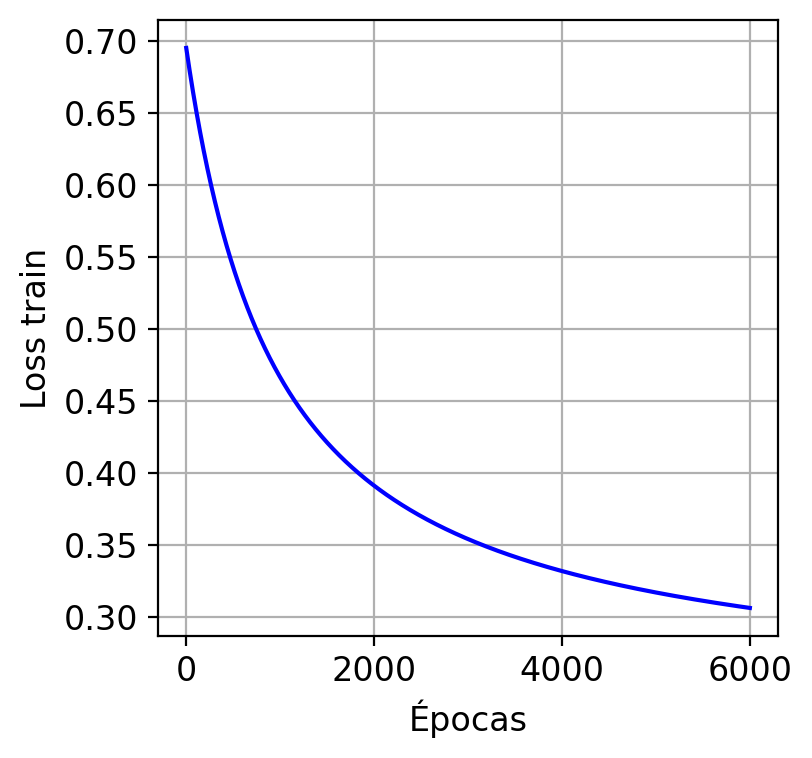

In [41]:
plt.figure(figsize=(4,4))
plt.plot(LR_all.loss_epochs,'-b',label='BCE Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss train')
plt.grid()

Podemos dibujar también los **pesos finales** del regresor logístico. Con `.detach()` desvinculamos el tensor de sus gradientes y luego pasamos a numpy array:

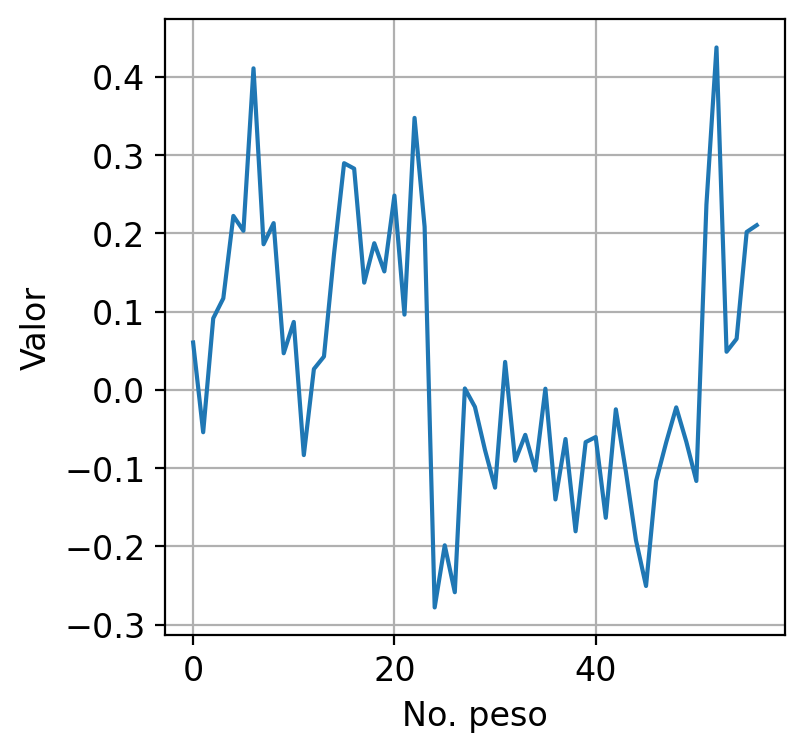

In [42]:
plt.figure(figsize=(4,4))

plt.plot(list(LR_all.parameters())[0].reshape([-1,]).detach().numpy())
plt.grid()
plt.xlabel('No. peso')
plt.ylabel('Valor')
plt.show()

### 5.3 - Evaluación del modelo en el conjunto de entrenamiento y test

Ahora que hemos entrenado a nuestro regresor logístico, es hora de **evaluar sus prestaciones** tanto en el conjunto de datos de **entrenamiento** como en el conjunto de **test**.

Con el siguiente código obtenemos la **salida del regresor logístico** para los datos los datos de **train** y **test** y representamos las curvas **ROC**.

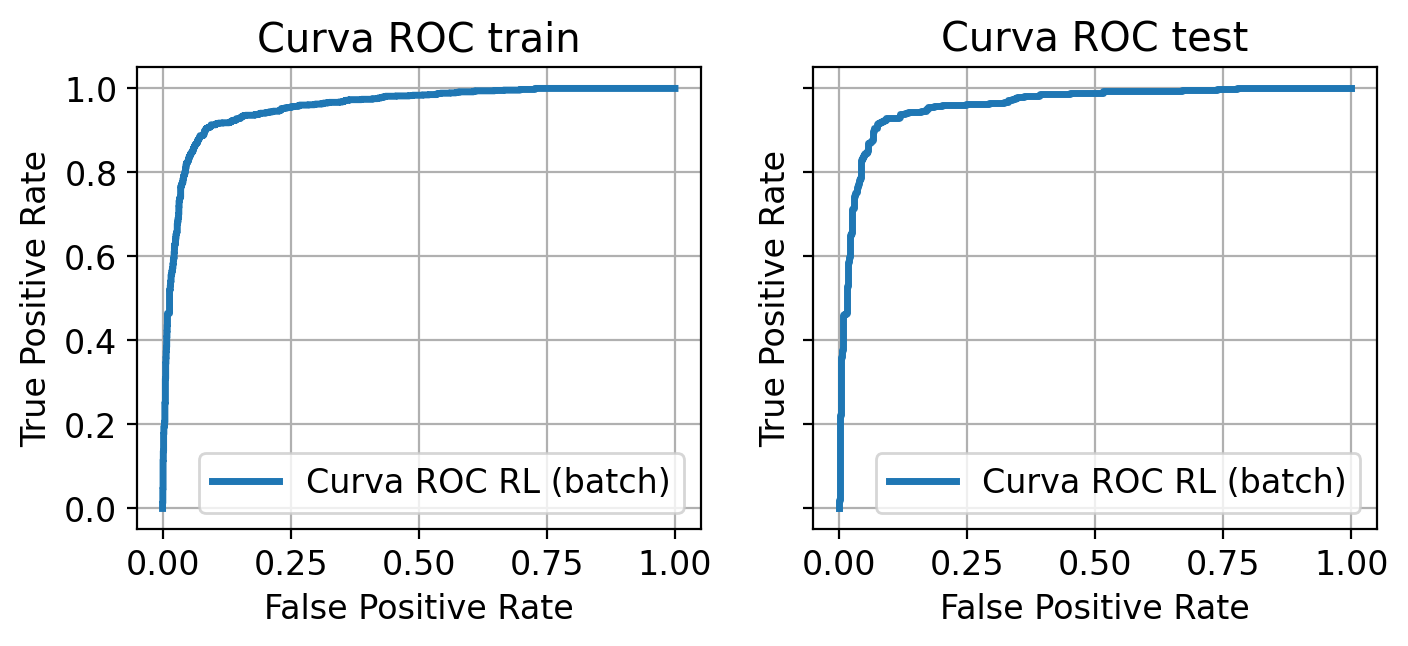

El área bajo la curva ROC de RL (batch) para train es:	 0.9550993302406305
El área bajo la curva ROC de RL (batch) para test es:	 0.9609060417151677


In [43]:
out_train_batch = LR_all.predict(X_train)
out_test_batch = LR_all.predict(X_test)

from sklearn import metrics

fpr_batch_train, tpr_batch_train, thresholds_batch_train = metrics.roc_curve(y_train, out_train_batch, pos_label=1)
fpr_batch_test, tpr_batch_test, thresholds_batch_test = metrics.roc_curve(y_test, out_test_batch, pos_label=1)

fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=True)
fig.add_subplot(axes[0])
plt.plot(fpr_batch_train, tpr_batch_train, lw=2.5,label='Curva ROC RL (batch)')
plt.legend(loc='best')
#plt.grid(b=True, which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC train')

fig.add_subplot(axes[1])
plt.plot(fpr_batch_test, tpr_batch_test, lw=2.5,label='Curva ROC RL (batch)')
plt.legend(loc='best')
#plt.grid(b=True, which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC test')

plt.show()

area_roc_batch_train = metrics.roc_auc_score(y_train, out_train_batch)
area_roc_batch_test = metrics.roc_auc_score(y_test, out_test_batch)

print("El área bajo la curva ROC de RL (batch) para train es:\t {}".format(area_roc_batch_train))
print("El área bajo la curva ROC de RL (batch) para test es:\t {}".format(area_roc_batch_test))

### 5.4 - Entrenamiento con "minibatches"

Cuando el número de **datos de entrenamiento** es **muy grande**, resulta **poco eficiente** calcular el gradiente en cada paso con **TODOS** los datos. **Se puede alcanzar las mismas características de convergencia utilizando únicamente una parte de los datos en cada paso del descenso por gradiente**.

Veamos, por tanto, una **forma más eficiente de alcanzar la convergencia**:

- Dividimos el entrenamiento en **"épocas"**. Durante cada época se recorre completamente el conjunto de entrenamiento.

- Cada época se compone de varias **iteraciones**, en cada iteración sólo se visita una parte de los datos de entrenamiento (**batch**).

- Cada iteración se descompone a su vez en **mini-batches**, y en cada uno de ellos se calcula un gradiente y se actualizan los pesos del modelo.

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/minibatch.png' width=600 />
</center>




Procediendo de este modo, el descenso hacia el mínimo se vuelve **algo más ruidoso**, ya que cada paso se calcula ahora con **información parcial de los datos**. Cuando se utiliza únicamente **un dato** (o un **subconjunto muy pequeño de datos**) para calcular el gradiente, obtenemos el método de **descenso estocástico por gradiente** ([**"Stochastic Gradient Descent", SGD**](https://www.geeksforgeeks.org/difference-between-batch-gradient-descent-and-stochastic-gradient-descent/)). La aproximación **mini-batch** aquí descrita supone un caso intermedio entre ambas opciones:
  
<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/SGD_minibatch_batch.png' width=500 />
</center>




El concepto de **época** se refiere a un ciclo de aprendizaje en el que **se han usado todos los datos de entrenamiento**. En la aproximación **"batch"**, se calcula el **gradiente con todos los datos** y se aplica el **descenso una vez en cada época**.

En la aproximación **"mini-batch"**, **en cada época se calculan numerosos gradientes con una fracción de los datos y se realiza el descenso más veces**. Por ejemplo, si usamos $N$ iteraciones y $M$ minibatches, **estamos actualizando el modelo** $M \times N$ **veces por época**. Además, cada paso del gradiente se calcula con **menos operaciones**, ya que sólo se usa una fracción de los datos.   

En todo caso, en ambas aproximaciones, después de cada época, **todos los puntos de datos** se han utilizado en el optimizador una vez.

Vamos por tanto a implementar una **versión escalable** del entrenamiento de descenso de gradiente implementado anteriormente, usando el esquema de **mini-batches** recién descrito.



In [44]:
class LR_train_minibatch_NN(LR_NN):

    def __init__(self,dimx,num_train_data,
                 epochs=100,lr=0.001,batch_size=50,print_every=20):

        super().__init__(dimx)
        self.lr = lr #Learning Rate
        self.optim = optim.SGD(self.parameters(), self.lr)
        self.epochs = epochs

        self.print_every = print_every  # Print loss every
        self.criterion = nn.BCELoss()

        # A list to store the loss evolution along training
        self.loss_epochs = []
        self.batch_size = batch_size
        self.num_train = num_train_data
        self.num_batchs = np.floor(self.num_train/self.batch_size)

    def fit(self,x,y):

        # Bucle sobre las épochas
        for e in range(int(self.epochs)):
            # Permutamos los datos aleatoriamente en cada época
            idx = np.random.permutation(self.num_train)
            running_loss = 0.

            for i in range(int(self.num_batchs)):
                self.optim.zero_grad()  #Reiniciamos gradientes

                # Indices de los datos que participan en el batch
                idx_batch = idx[i*self.batch_size:(i+1)*self.batch_size]

                # Salida de la NN para el batch
                out_batch = self.forward(x[idx_batch,:])

                #Función de coste par el batch
                loss = self.criterion(out_batch,y[idx_batch].view(self.batch_size,1))
                running_loss += loss.item()

                #Calculamos gradientes
                loss.backward()

                #Una iteración de descenso por gradiente
                self.optim.step()

            self.loss_epochs.append(running_loss/self.num_batchs)

            if(e % self.print_every == 0): # Every 10 epochs
                print("Training loss after %d epochs: %f"
                      %(e,self.loss_epochs[-1]))

    def predict(self,X):
      # La entrada es una variable Numpy
      X_tensor = torch.tensor(X)
      # Calculamos las predicciones, las desligamos del tensor y las convertimos en un Numpy array 1-D
      predictions = self.forward(X_tensor).detach().numpy().reshape([-1,])
      return predictions


#### Ejercicio

Entrene un regresor logístico con descenso de gradiente estocástico minibatch con tamaño de batch 100, durante 500 épocas, y dibuje la evolución de la función de pérdida. Continúe el entrenamiento hasta que la curva de aprendizaje alcance una saturación en la convergencia.

#### Solución

In [45]:
N_epochs = 1000
Minibatch_size = 100

LR_minibatch = LR_train_minibatch_NN(X_train.shape[1],num_train_data=X_train.shape[0],epochs=N_epochs,
                              batch_size=Minibatch_size,lr=0.001,print_every=100)

In [46]:
LR_minibatch.fit(torch.tensor(X_train),torch.tensor(y_train))

Training loss after 0 epochs: 0.715688
Training loss after 100 epochs: 0.355753
Training loss after 200 epochs: 0.304921
Training loss after 300 epochs: 0.288655
Training loss after 400 epochs: 0.275866
Training loss after 500 epochs: 0.269385
Training loss after 600 epochs: 0.264425
Training loss after 700 epochs: 0.259681
Training loss after 800 epochs: 0.255197
Training loss after 900 epochs: 0.253569


Comparemos la convergencia de ambas aproximaciones **en función del número de épocas**:

Text(0, 0.5, 'Loss')

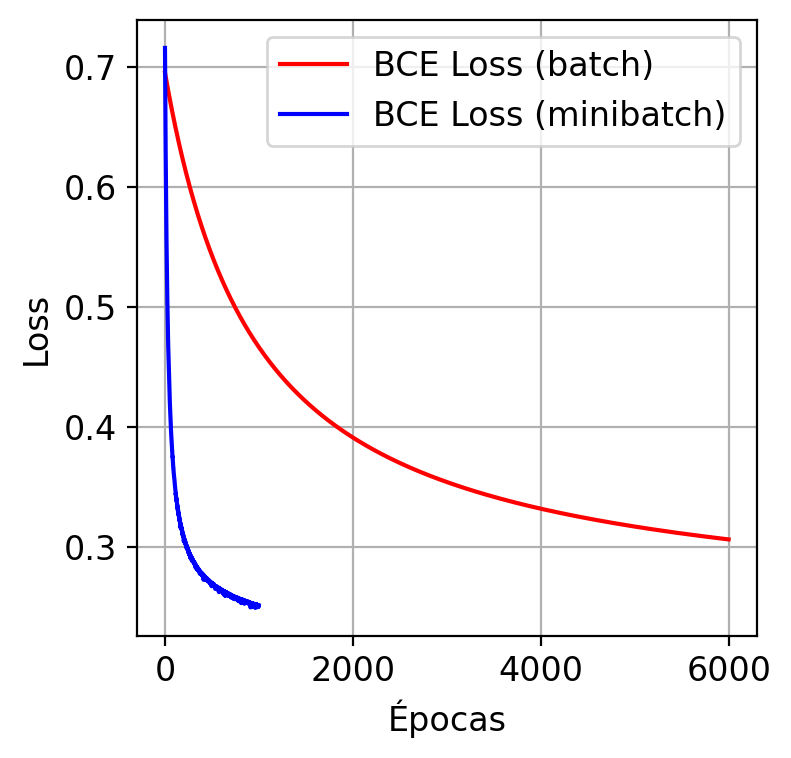

In [47]:
plt.figure(figsize=(4,4))
plt.plot(LR_all.loss_epochs,'-r',label='BCE Loss (batch)')
plt.plot(LR_minibatch.loss_epochs,'-b',label='BCE Loss (minibatch)')
plt.grid()
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Loss')

Vemos que a igual número de épocas, **el entrenamiento "mini-batch" es mucho más rápido**, pues se actualizan los gradientes con mucha más frecuencia.

#### Ejercicio

Para el RL entrenado, dibuje la curva ROC y determine el área bajo la curva

#### Solución

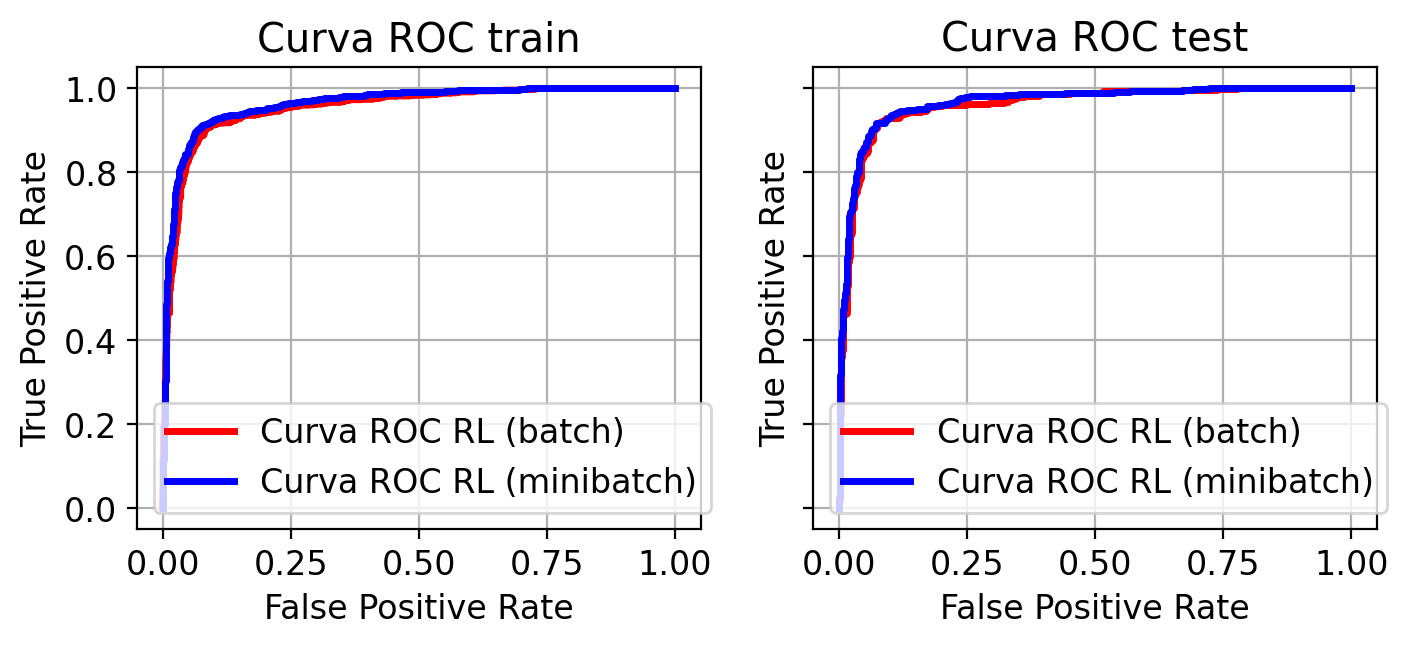

El área bajo la curva ROC de RL (batch) para train es:	 0.9550993302406305
El área bajo la curva ROC de RL (minib) para train es:	 0.9639339636183317

El área bajo la curva ROC de RL (batch) para test es:	 0.9609060417151677
El área bajo la curva ROC de RL (minib) para test es:	 0.9660773256766426


In [48]:
from sklearn import metrics
out_train_batch = LR_all.forward(torch.tensor(X_train)).detach().numpy().reshape([-1,])
out_test_batch = LR_all.forward(torch.tensor(X_test)).detach().numpy().reshape([-1,])

out_train_minibatch = LR_minibatch.forward(torch.tensor(X_train)).detach().numpy().reshape([-1,])
out_test_minibatch = LR_minibatch.forward(torch.tensor(X_test)).detach().numpy().reshape([-1,])

fpr_batch_train, tpr_batch_train, thresholds_batch_train = metrics.roc_curve(y_train, out_train_batch, pos_label=1)
fpr_batch_test, tpr_batch_test, thresholds_batch_test = metrics.roc_curve(y_test, out_test_batch, pos_label=1)

fpr_minibatch_train, tpr_minibatch_train, thresholds_minibatch_train = metrics.roc_curve(y_train, out_train_minibatch, pos_label=1)
fpr_minibatch_test, tpr_minibatch_test, thresholds_minibatch_test = metrics.roc_curve(y_test, out_test_minibatch, pos_label=1)


fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=True)
fig.add_subplot(axes[0])
plt.plot(fpr_batch_train, tpr_batch_train, 'r', lw=2.5,label='Curva ROC RL (batch)')
plt.plot(fpr_minibatch_train, tpr_minibatch_train, 'b', lw=2.5,label='Curva ROC RL (minibatch)')
plt.legend(loc='best')
#plt.grid(b=True, which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC train')

fig.add_subplot(axes[1])
plt.plot(fpr_batch_test, tpr_batch_test, 'r', lw=2.5,label='Curva ROC RL (batch)')
plt.plot(fpr_minibatch_test, tpr_minibatch_test, 'b', lw=2.5,label='Curva ROC RL (minibatch)')
plt.legend(loc='best')
#plt.grid(b=True, which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC test')

plt.show()

area_roc_batch_train = metrics.roc_auc_score(y_train, out_train_batch)
area_roc_minibatch_train = metrics.roc_auc_score(y_train, out_train_minibatch)

area_roc_batch_test = metrics.roc_auc_score(y_test, out_test_batch)
area_roc_minibatch_test = metrics.roc_auc_score(y_test, out_test_minibatch)

print("El área bajo la curva ROC de RL (batch) para train es:\t {}".format(area_roc_batch_train))
print("El área bajo la curva ROC de RL (minib) para train es:\t {}".format(area_roc_minibatch_train))

print("\nEl área bajo la curva ROC de RL (batch) para test es:\t {}".format(area_roc_batch_test))
print("El área bajo la curva ROC de RL (minib) para test es:\t {}".format(area_roc_minibatch_test))



Observamos también que las prestaciones tras utilizar "mini-batch" son ligeramente mejores, pues hemos optimizado más la función de coste.

###  6 - Entrenando un MLP

Vamos a modificar el código anterior para implementar una red neuronal de tipo **Perceptrón Multicapa, MLP**. Utilizando pytorch esta generalización es relativamente sencilla, pues la estructura principal de las clases se mantiene.

Supongamos que queremos definir un MLP con **tres capas**, todas usando **unidades lineales rectificadas (RELU)** como activaciones no lineales, excepto la **última capa, que usa una sigmoide**. La **primera capa oculta** tiene **20 neuronas** y la **segunda capa oculta** tendrá **10**.

Al igual que con el LR, creamos una clase que defina el modelo y luego una clase más grande de la que hereda para incorporar el entrenamiento.



In [49]:
class MLP(nn.Module):
  # Modelo con 3 capas.

  #Definimos como inputs del constructor la dimensión de los datos y el número de unidades ocultas en las dos capas intermedias
  def __init__(self,dimx, n_hidden1, n_hidden2):
    super().__init__()

    # Los tamaños de entrada y salida de las capas deben ser coherentes:
    self.capa1 = nn.Linear(dimx, n_hidden1) # Primera capa lineal
    self.capa2 = nn.Linear(n_hidden1, n_hidden2) # Segunda capa lineal
    self.capa_final = nn.Linear(n_hidden2, 1) # Tercera capa lineal. Salida es un escalar

    self.relu = nn.ReLU() # Activación para en las capas 1 y 2
    self.sigmoid = nn.Sigmoid() # Activación para la capa de salida

  def forward(self, x):
    # Definimos la secuencia de operaciones para determinar la salida

    # Primera capa:
    x = self.capa1(x)
    x = self.relu(x)

    # Segunda capa:
    x = self.capa2(x)
    x = self.relu(x)

    # Capa de salida:
    x = self.capa_final(x)
    x = self.sigmoid(x)

    return x

**Extendemos la clase** añadiendo entrenamiento SGD estocástico con minibatchs.


In [50]:
class MLP_train_minibatch(MLP):

  def __init__(self, dimx, n_hidden1, n_hidden2, num_train_data,
                epochs=100, lr=0.001, batch_size=50, print_every=20):

    super().__init__(dimx, n_hidden1, n_hidden2)  #Inicializamos la clase padre
    self.lr = lr #Learning Rate
    self.optim = optim.Adam(self.parameters(), self.lr)
    self.epochs = epochs
    self.print_every = print_every  # Print loss every
    self.criterion = nn.BCELoss()

    # A list to store the loss evolution along training
    self.loss_epochs = []
    self.batch_size = batch_size
    self.num_train = num_train_data

    self.num_batchs = np.floor(self.num_train/self.batch_size)

  def fit(self,x,y):

    # Bucle sobre las épocas
    for e in range(int(self.epochs)):

      # Permutamos los datos aleatoriamente en cada época
      idx = np.random.permutation(self.num_train)
      running_loss = 0.

      for i in range(int(self.num_batchs)):
        self.optim.zero_grad()  #Reiniciamos gradientes

        # Indices de los datos que participan en el batch
        idx_batch = idx[i*self.batch_size:(i+1)*self.batch_size]

        # Salida de la NN para el batch
        out = self.forward(x[idx_batch,:])

        #Función de coste par el batch
        loss = self.criterion(out,y[idx_batch].view(self.batch_size,1))
        running_loss += loss.item()

        #Calculamos gradientes
        loss.backward()

        #Una iteración de descenso por gradiente
        self.optim.step()

      self.loss_epochs.append(running_loss/self.num_batchs)

      if(e % self.print_every == 0): # Every 10 epochs
        print("Training loss after %d epochs: %f"%(e,self.loss_epochs[-1]))


#### Ejercicio

Instancia una red MLP usando la clase **``MLP_train_minibatch``** recién definida. Recuerde que **la primera capa oculta debe tener 20 neuronas y la segunda capa oculta 10**.

Entrene dicha red durante **200 épocas** y obtenga la curva ROC. Compárela con la curva ROC del RL.

#### Solución

In [51]:
N_hidden1 = 20
N_hidden2 = 10
N_epochs = 1000

MLP_minibatch = MLP_train_minibatch(X_train.shape[1], N_hidden1, N_hidden2, num_train_data=X_train.shape[0],epochs=N_epochs,
                              batch_size=100,lr=0.001,print_every=10)

MLP_minibatch.fit(torch.tensor(X_train),torch.tensor(y_train))

Training loss after 0 epochs: 0.705147
Training loss after 10 epochs: 0.191826
Training loss after 20 epochs: 0.153128
Training loss after 30 epochs: 0.134659
Training loss after 40 epochs: 0.118518
Training loss after 50 epochs: 0.108522
Training loss after 60 epochs: 0.099472
Training loss after 70 epochs: 0.090406
Training loss after 80 epochs: 0.083178
Training loss after 90 epochs: 0.078324
Training loss after 100 epochs: 0.075003
Training loss after 110 epochs: 0.068848
Training loss after 120 epochs: 0.064110
Training loss after 130 epochs: 0.056835
Training loss after 140 epochs: 0.055183
Training loss after 150 epochs: 0.053057
Training loss after 160 epochs: 0.050660
Training loss after 170 epochs: 0.047988
Training loss after 180 epochs: 0.046408
Training loss after 190 epochs: 0.043034
Training loss after 200 epochs: 0.041429
Training loss after 210 epochs: 0.044592
Training loss after 220 epochs: 0.038720
Training loss after 230 epochs: 0.036532
Training loss after 240 epo

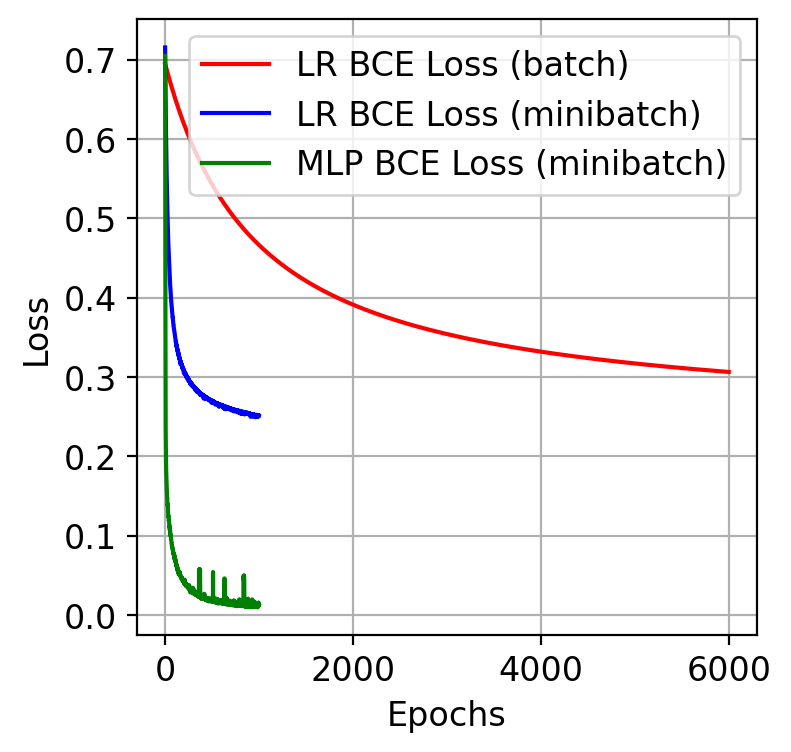

In [52]:
plt.figure(figsize=(4,4))
plt.plot(LR_all.loss_epochs,'-r',label='LR BCE Loss (batch)')
plt.plot(LR_minibatch.loss_epochs,'-b',label='LR BCE Loss (minibatch)')
plt.plot(MLP_minibatch.loss_epochs,'-g',label='MLP BCE Loss (minibatch)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend()

Observamos que el modelo MLP alcanza menores valores de "Loss" durante el entrenamiento que el LR, como era de esperar al ser un modelo mucho más complejo y con más grados de libertad.

La convergencia del gradiente estocástico en modo minibatch es mucho más rápida. Alcanzamos una saturación o estancamiento en la curva de convergencia, no haría falta emplear más iteraciones/épocas. Se observa cierta oscilación al final de las curvas, debido al gradiente estocástico.

Evaluemos las prestaciones (curva ROC) y comparemos con los resultados del Regresor Logístico:

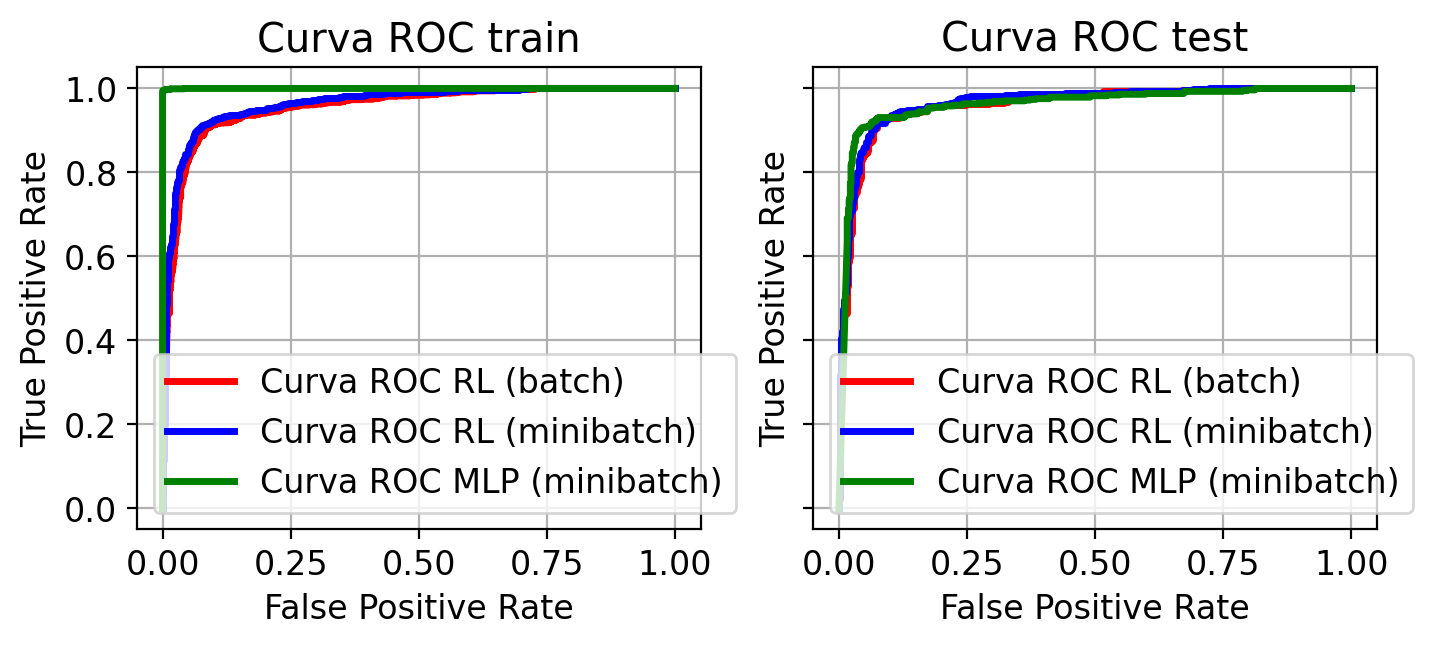

El área bajo la curva ROC de RL (batch) para train es:	 0.9550993302406305
El área bajo la curva ROC de RL (minib) para train es:	 0.9639339636183317
El área bajo la curva ROC de MLP (minib) para train es:	 0.9999282284163274

El área bajo la curva ROC de RL (batch) para test es:	 0.9609060417151677
El área bajo la curva ROC de RL (minib) para test es:	 0.9660773256766426
El área bajo la curva ROC de MLP (minib) para test es:	 0.9621185666123455


In [53]:
out_train_MLP = MLP_minibatch.forward(torch.tensor(X_train)).detach().numpy().reshape([-1,])
out_test_MLP = MLP_minibatch.forward(torch.tensor(X_test)).detach().numpy().reshape([-1,])

fpr_MLP_train, tpr_MLP_train, thresholds_MLP_train = metrics.roc_curve(y_train, out_train_MLP, pos_label=1)
fpr_MLP_test, tpr_MLP_test, thresholds_MLP_test = metrics.roc_curve(y_test, out_test_MLP, pos_label=1)

fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=True)
fig.add_subplot(axes[0])
plt.plot(fpr_batch_train, tpr_batch_train, 'r', lw=2.5,label='Curva ROC RL (batch)')
plt.plot(fpr_minibatch_train, tpr_minibatch_train, 'b', lw=2.5,label='Curva ROC RL (minibatch)')
plt.plot(fpr_MLP_train, tpr_MLP_train, 'g', lw=2.5,label='Curva ROC MLP (minibatch)')
plt.legend(loc='best')
#plt.grid(b=True, which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC train')

fig.add_subplot(axes[1])
plt.plot(fpr_batch_test, tpr_batch_test, 'r', lw=2.5,label='Curva ROC RL (batch)')
plt.plot(fpr_minibatch_test, tpr_minibatch_test, 'b', lw=2.5,label='Curva ROC RL (minibatch)')
plt.plot(fpr_MLP_test, tpr_MLP_test, 'g', lw=2.5,label='Curva ROC MLP (minibatch)')
plt.legend(loc='best')
#plt.grid(b=True, which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC test')

plt.show()

area_roc_batch_train = metrics.roc_auc_score(y_train, out_train_batch)
area_roc_minibatch_train = metrics.roc_auc_score(y_train, out_train_minibatch)

area_roc_batch_test = metrics.roc_auc_score(y_test, out_test_batch)
area_roc_minibatch_test = metrics.roc_auc_score(y_test, out_test_minibatch)

area_roc_MLP_train = metrics.roc_auc_score(y_train, out_train_MLP)
area_roc_MLP_test = metrics.roc_auc_score(y_test, out_test_MLP)

print("El área bajo la curva ROC de RL (batch) para train es:\t {}".format(area_roc_batch_train))
print("El área bajo la curva ROC de RL (minib) para train es:\t {}".format(area_roc_minibatch_train))
print("El área bajo la curva ROC de MLP (minib) para train es:\t {}".format(area_roc_MLP_train))

print("\nEl área bajo la curva ROC de RL (batch) para test es:\t {}".format(area_roc_batch_test))
print("El área bajo la curva ROC de RL (minib) para test es:\t {}".format(area_roc_minibatch_test))
print("El área bajo la curva ROC de MLP (minib) para test es:\t {}".format(area_roc_MLP_test))



Vemos que el nuevo modelo MLP mejora mucho las prestaciones sobre el conjunto de entrenamiento, debido a su mayor complejidad y grados de libertad, pero dicha mejora es más modesta cuando evaluamos sobre el conjunto de test.

Las prestaciones en entrenamiento son más elevadas que en test. Esto será un claro síntoma de **"sobre-entrenamiento"** (**"over-fitting"**), un concepto que veremos en temas posteriores. Pese a ello, las prestaciones en test han mejorado ligeramente.

### Ejercicio de ampliación:

Modifique la clase ``MLP_train_minibatch`` añadiendo un método predict que reciba entradas y devuelva salidas en formato ``Numpy``.

## 7 - Guardar y restaurar modelos

Finalmente, vamos a mostrar cómo **almacenar** y **recuperar** modelos (es decir, los valores de los parámetros) con PyTorch. Esto es importante porque a menudo querremos recuperar modelos previamente entrenados para usarlos al hacer predicciones o continuar entrenando con datos nuevos.

Los **parámetros para las redes PyTorch se almacenan en un diccionario denominado `state_dict`**. Este diccionario contiene las matrices de peso y sesgo para cada una de nuestras capas.

In [54]:
print("Nuestro modelo: \n\n", MLP_minibatch, '\n')
print("Los valores almacenados en state dict son: \n\n", MLP_minibatch.state_dict().keys())

print("Por ejemplo, los pesos de la segunda capa son:\n")
print( MLP_minibatch.state_dict()["capa_final.weight"])

Nuestro modelo: 

 MLP_train_minibatch(
  (capa1): Linear(in_features=57, out_features=20, bias=True)
  (capa2): Linear(in_features=20, out_features=10, bias=True)
  (capa_final): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (criterion): BCELoss()
) 

Los valores almacenados en state dict son: 

 odict_keys(['capa1.weight', 'capa1.bias', 'capa2.weight', 'capa2.bias', 'capa_final.weight', 'capa_final.bias'])
Por ejemplo, los pesos de la segunda capa son:

tensor([[ 1.7307,  2.0029,  5.1212, -1.4427, -1.2455,  2.3767,  1.9980,  4.4438,
          2.4377,  2.9157]])


Para **guardar el modelo, usaremos `torch.save`**. Guardaremos los archivos con extension `.pth`, para hacer explícito que se han generado con pytorch.

In [55]:
import os

# Set files location (local)
MYDRIVE = "/Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/9_MaterialComplementario/"

torch.save(MLP_minibatch.state_dict(), MYDRIVE + 'MLP_spam.pth')

print("\nModelo MLP guardado en {}".format(MYDRIVE + 'MLP_spam.pth'))


Modelo MLP guardado en /Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/9_MaterialComplementario/MLP_spam.pth


Podemos recuperar el diccionario con **`torch.load`** e insertar **`state_dict`** en una nueva red con `my_MLP.load_state_dict(state_dict)`. Para ello definimos primero una **red no entrenada** con las **mismas dimensiones que la almacenada**, y posteriormente **actualizamos sus pesos** usando ``load_state_dict``.  

In [56]:
# Recuperamos los pesos almacenados
state_dict = torch.load(MYDRIVE + 'MLP_spam.pth')

# Identificamos parámetros de la red almacenada (tamaño de las capas ocultas)
n_hidden1 = state_dict['capa1.weight'].shape[0]
n_hidden2 = state_dict['capa2.weight'].shape[0]

# Definimos nueva red con MISMAS DIMENSIONES
loaded_MLP = MLP_train_minibatch(X_train.shape[1], n_hidden1, n_hidden2, num_train_data=X_train.shape[0],epochs=100,
                              batch_size=100,lr=0.001,print_every=10)

# Insertamos pesos en la nueva red
loaded_MLP.load_state_dict(state_dict)

<All keys matched successfully>

In [57]:
# Comprobamos prestaciones de la red recuperada:
out_test_MLP = loaded_MLP.forward(torch.tensor(X_test)).detach().numpy().reshape([-1,])
fpr_MLP_test, tpr_MLP_test, thresholds_MLP_test = metrics.roc_curve(y_test, out_test_MLP, pos_label=1)
area_roc_MLP_test = metrics.roc_auc_score(y_test, out_test_MLP)
print("El área bajo la curva ROC de MLP (minib) para test es:\t {}".format(area_roc_MLP_test))


El área bajo la curva ROC de MLP (minib) para test es:	 0.9621185666123455


**Importante: `load_state_dict` nos dará un error si la arquitectura de la red es differente de la que hemos salvado en el archivo pth.**

## 8 - Elección de hiperparámetros

Vemos que los nuevos modelos presentan numerosas posibles variantes en función del número de capas que se utilicen, el número de neuronas por capa, el tipo de activación en cada capa, etc.

En próximos temas trataremos más a fondo el problema de elección de hiperparámetros. De momento, hagamos un ejercicio para explorar distintas variantes del modelo MLP.

### Ejercicio  de ampliación:

Explore otros hiperparámetros de la red MLP para conseguir máximas prestaciones. ¿Cree que es adecuado utilizar el conjunto de test para elegir dichos hiperparámetros?

In [58]:
### Ejercicio 1: Exploración de hiperparámetros
# NO es adecuado usar el conjunto de test para elegir hiperparámetros,
# ya que estaríamos "contaminando" la evaluación final.
# Se debe usar un conjunto de validación separado del test.

from sklearn.model_selection import train_test_split as tts
from sklearn import metrics

# Crear conjunto de validación a partir del train
X_tr, X_val, y_tr, y_val = tts(X_train, y_train, test_size=0.2, random_state=42)

# Definir grid de hiperparámetros
configs = [
    {'n_hidden1': 10, 'n_hidden2': 5,  'lr': 0.001, 'batch_size': 50},
    {'n_hidden1': 20, 'n_hidden2': 10, 'lr': 0.001, 'batch_size': 50},
    {'n_hidden1': 50, 'n_hidden2': 25, 'lr': 0.001, 'batch_size': 50},
    {'n_hidden1': 20, 'n_hidden2': 10, 'lr': 0.0005, 'batch_size': 50},
    {'n_hidden1': 20, 'n_hidden2': 10, 'lr': 0.005, 'batch_size': 50},
    {'n_hidden1': 20, 'n_hidden2': 10, 'lr': 0.001, 'batch_size': 100},
    {'n_hidden1': 40, 'n_hidden2': 20, 'lr': 0.001, 'batch_size': 100},
]

results = []
best_auc = 0
best_model = None
best_config = None

for cfg in configs:
    model = MLP_train_minibatch(
        X_tr.shape[1], cfg['n_hidden1'], cfg['n_hidden2'],
        num_train_data=X_tr.shape[0], epochs=200,
        lr=cfg['lr'], batch_size=cfg['batch_size'], print_every=999
    )
    model.fit(torch.tensor(X_tr), torch.tensor(y_tr))

    # Evaluar en validación
    out_val = model.forward(torch.tensor(X_val)).detach().numpy().reshape(-1)
    auc_val = metrics.roc_auc_score(y_val, out_val)
    acc_val = metrics.accuracy_score(y_val, (out_val > 0.5).astype(int))

    results.append({**cfg, 'auc_val': auc_val, 'acc_val': acc_val})
    print(f"h1={cfg['n_hidden1']:2d}, h2={cfg['n_hidden2']:2d}, lr={cfg['lr']:.4f}, bs={cfg['batch_size']:3d} => AUC_val={auc_val:.4f}, Acc_val={acc_val:.4f}")

    if auc_val > best_auc:
        best_auc = auc_val
        best_model = model
        best_config = cfg

print(f"\nMejor configuración: {best_config} con AUC_val={best_auc:.4f}")

# Evaluamos el mejor modelo en TEST (solo una vez, al final)
out_test = best_model.forward(torch.tensor(X_test)).detach().numpy().reshape(-1)
auc_test = metrics.roc_auc_score(y_test, out_test)
acc_test = metrics.accuracy_score(y_test, (out_test > 0.5).astype(int))
print(f"Prestaciones en TEST del mejor modelo: AUC={auc_test:.4f}, Acc={acc_test:.4f}")

Training loss after 0 epochs: 0.668753
h1=10, h2= 5, lr=0.0010, bs= 50 => AUC_val=0.9628, Acc_val=0.9130
Training loss after 0 epochs: 0.656749
h1=20, h2=10, lr=0.0010, bs= 50 => AUC_val=0.9702, Acc_val=0.9239
Training loss after 0 epochs: 0.568680
h1=50, h2=25, lr=0.0010, bs= 50 => AUC_val=0.9748, Acc_val=0.9255
Training loss after 0 epochs: 0.659944
h1=20, h2=10, lr=0.0005, bs= 50 => AUC_val=0.9710, Acc_val=0.9115
Training loss after 0 epochs: 0.425219
h1=20, h2=10, lr=0.0050, bs= 50 => AUC_val=0.9671, Acc_val=0.9146
Training loss after 0 epochs: 0.686632
h1=20, h2=10, lr=0.0010, bs=100 => AUC_val=0.9720, Acc_val=0.9146
Training loss after 0 epochs: 0.653958
h1=40, h2=20, lr=0.0010, bs=100 => AUC_val=0.9696, Acc_val=0.9193

Mejor configuración: {'n_hidden1': 50, 'n_hidden2': 25, 'lr': 0.001, 'batch_size': 50} con AUC_val=0.9748
Prestaciones en TEST del mejor modelo: AUC=0.9708, Acc=0.9218


### Ejercicio  de ampliación:

Modifique la clase ``MLP_train_minibatch`` para calcular la evolución de las prestaciones usando un conjunto de datos de validación. Considere almacenar diferentes medidas de prestaciones: loss, accuracy, AUC, etc.

Epoch    0 | Train Loss=0.6399 Acc=0.7345 AUC=0.9192 | Val Loss=0.6387 Acc=0.7484 AUC=0.9261
Epoch   25 | Train Loss=0.1394 Acc=0.9472 AUC=0.9871 | Val Loss=0.2040 Acc=0.9270 AUC=0.9725
Epoch   50 | Train Loss=0.1077 Acc=0.9612 AUC=0.9922 | Val Loss=0.2169 Acc=0.9224 AUC=0.9719
Epoch   75 | Train Loss=0.0859 Acc=0.9713 AUC=0.9948 | Val Loss=0.2362 Acc=0.9208 AUC=0.9716
Epoch  100 | Train Loss=0.0672 Acc=0.9798 AUC=0.9967 | Val Loss=0.2598 Acc=0.9193 AUC=0.9704
Epoch  125 | Train Loss=0.0548 Acc=0.9845 AUC=0.9977 | Val Loss=0.2768 Acc=0.9270 AUC=0.9715
Epoch  150 | Train Loss=0.0449 Acc=0.9887 AUC=0.9984 | Val Loss=0.3076 Acc=0.9270 AUC=0.9708
Epoch  175 | Train Loss=0.0371 Acc=0.9876 AUC=0.9990 | Val Loss=0.3521 Acc=0.9270 AUC=0.9695
Epoch  200 | Train Loss=0.0311 Acc=0.9911 AUC=0.9993 | Val Loss=0.3717 Acc=0.9270 AUC=0.9695
Epoch  225 | Train Loss=0.0275 Acc=0.9911 AUC=0.9995 | Val Loss=0.4267 Acc=0.9224 AUC=0.9682
Epoch  250 | Train Loss=0.0233 Acc=0.9918 AUC=0.9996 | Val Loss=0.4742

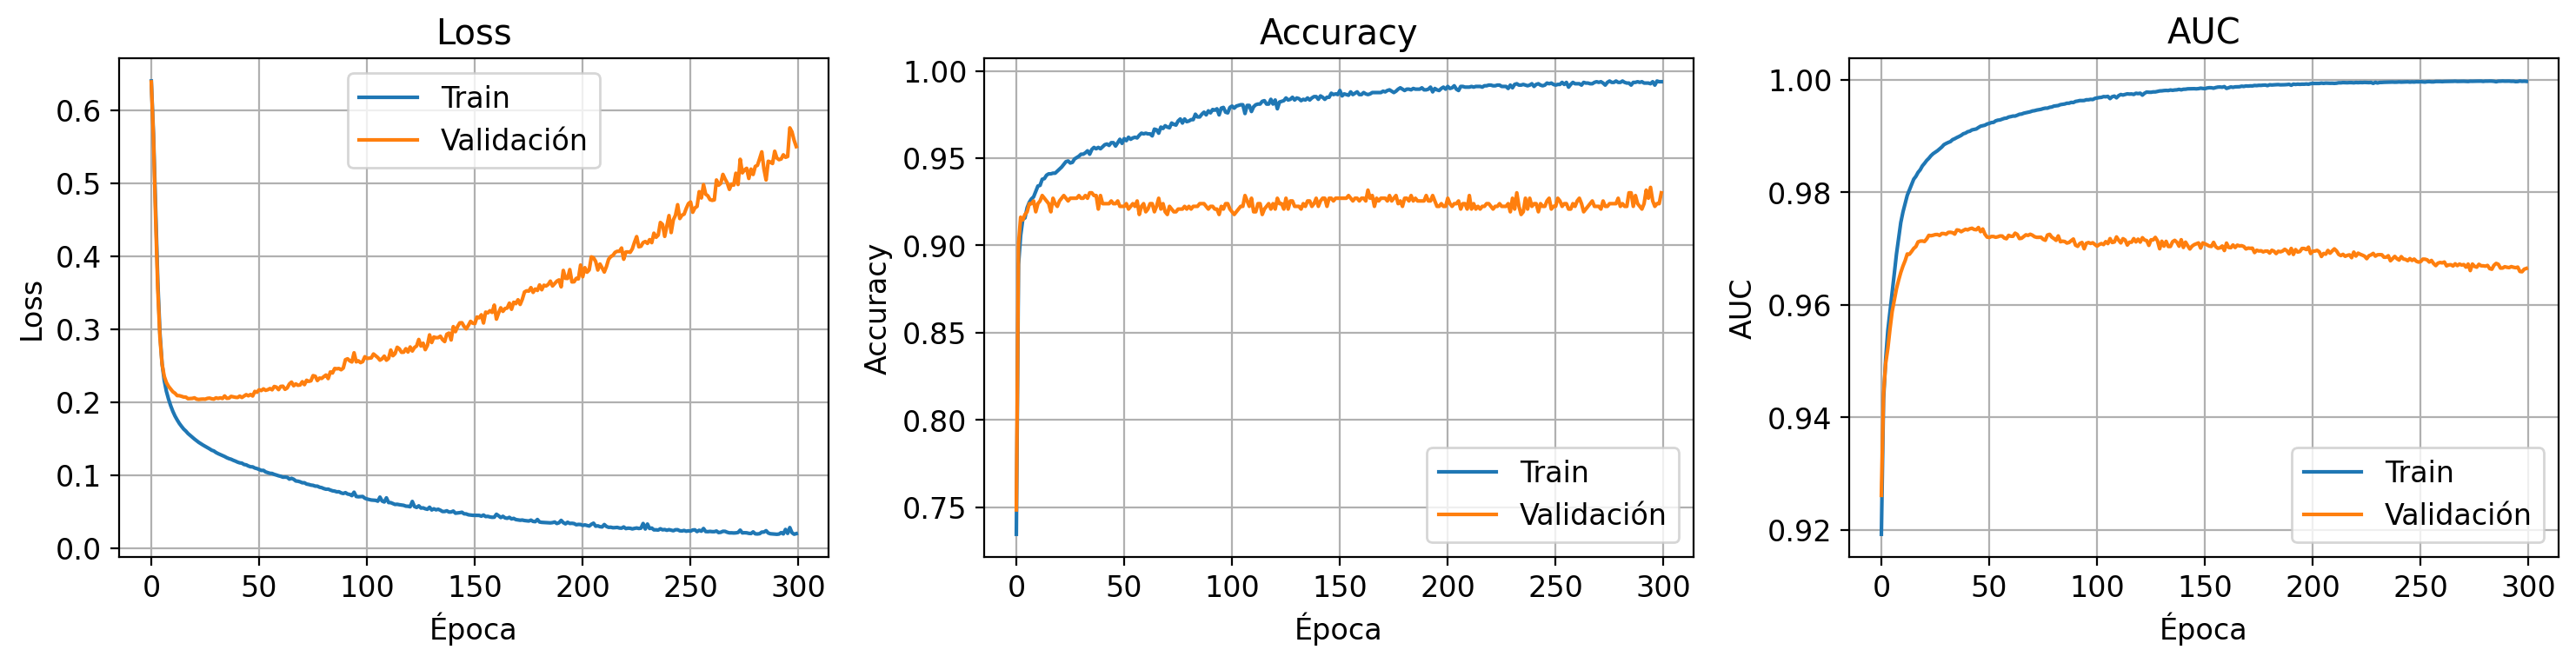

In [59]:
### Ejercicio 2: MLP_train_minibatch con métricas de validación

class MLP_train_validation(MLP):

    def __init__(self, dimx, n_hidden1, n_hidden2, num_train_data,
                 epochs=100, lr=0.001, batch_size=50, print_every=20):

        super().__init__(dimx, n_hidden1, n_hidden2)
        self.lr = lr
        self.optim = optim.Adam(self.parameters(), self.lr)
        self.epochs = epochs
        self.print_every = print_every
        self.criterion = nn.BCELoss()
        self.batch_size = batch_size
        self.num_train = num_train_data
        self.num_batchs = np.floor(self.num_train / self.batch_size)

        # Histórico de métricas
        self.train_loss_hist = []
        self.val_loss_hist = []
        self.train_acc_hist = []
        self.val_acc_hist = []
        self.train_auc_hist = []
        self.val_auc_hist = []

    def _evaluate(self, x, y):
        """Calcula loss, accuracy y AUC sobre un conjunto de datos."""
        with torch.no_grad():
            out = self.forward(x)
            loss = self.criterion(out, y.view(-1, 1)).item()
            preds = out.numpy().reshape(-1)
            y_np = y.numpy()
            acc = metrics.accuracy_score(y_np, (preds > 0.5).astype(int))
            auc = metrics.roc_auc_score(y_np, preds)
        return loss, acc, auc

    def fit(self, x_train, y_train, x_val, y_val):

        x_val_t = torch.tensor(x_val) if not isinstance(x_val, torch.Tensor) else x_val
        y_val_t = torch.tensor(y_val) if not isinstance(y_val, torch.Tensor) else y_val
        x_train_t = torch.tensor(x_train) if not isinstance(x_train, torch.Tensor) else x_train
        y_train_t = torch.tensor(y_train) if not isinstance(y_train, torch.Tensor) else y_train

        for e in range(int(self.epochs)):
            idx = np.random.permutation(self.num_train)
            running_loss = 0.

            for i in range(int(self.num_batchs)):
                self.optim.zero_grad()
                idx_batch = idx[i * self.batch_size:(i + 1) * self.batch_size]
                out = self.forward(x_train_t[idx_batch, :])
                loss = self.criterion(out, y_train_t[idx_batch].view(self.batch_size, 1))
                running_loss += loss.item()
                loss.backward()
                self.optim.step()

            # Métricas de train y validación al final de cada época
            tr_loss, tr_acc, tr_auc = self._evaluate(x_train_t, y_train_t)
            vl_loss, vl_acc, vl_auc = self._evaluate(x_val_t, y_val_t)

            self.train_loss_hist.append(tr_loss)
            self.val_loss_hist.append(vl_loss)
            self.train_acc_hist.append(tr_acc)
            self.val_acc_hist.append(vl_acc)
            self.train_auc_hist.append(tr_auc)
            self.val_auc_hist.append(vl_auc)

            if e % self.print_every == 0:
                print(f"Epoch {e:4d} | Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} AUC={tr_auc:.4f} | Val Loss={vl_loss:.4f} Acc={vl_acc:.4f} AUC={vl_auc:.4f}")

# Entrenar con validación
X_tr, X_val, y_tr, y_val = tts(X_train, y_train, test_size=0.2, random_state=42)

mlp_val = MLP_train_validation(
    X_tr.shape[1], 20, 10, num_train_data=X_tr.shape[0],
    epochs=300, lr=0.001, batch_size=100, print_every=25
)
mlp_val.fit(X_tr, y_tr, X_val, y_val)

# Visualizar evolución de métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (tr, vl, title) in zip(axes, [
    (mlp_val.train_loss_hist, mlp_val.val_loss_hist, 'Loss'),
    (mlp_val.train_acc_hist, mlp_val.val_acc_hist, 'Accuracy'),
    (mlp_val.train_auc_hist, mlp_val.val_auc_hist, 'AUC'),
]):
    ax.plot(tr, label='Train')
    ax.plot(vl, label='Validación')
    ax.set_xlabel('Época')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

### Ejercicio  de ampliación:

Implemente el método de ``early stopping``, eligiendo el modelo que alcanza un mínimo en las prestaciones del conjunto de validación. Nota: a fin de no repetir el entrenamiento, puede considerar almacenar todos los modelos intermedios.

Epoch    0 | Train Loss=0.6496 | Val Loss=0.6257 | Best=0.6257 (ep 0)
Epoch   25 | Train Loss=0.1388 | Val Loss=0.2001 | Best=0.1998 (ep 24)
Epoch   50 | Train Loss=0.1061 | Val Loss=0.2058 | Best=0.1985 (ep 27)

Early stopping en época 57. Mejor época: 27 con Val Loss=0.1985
Modelo restaurado a los pesos de la época 27


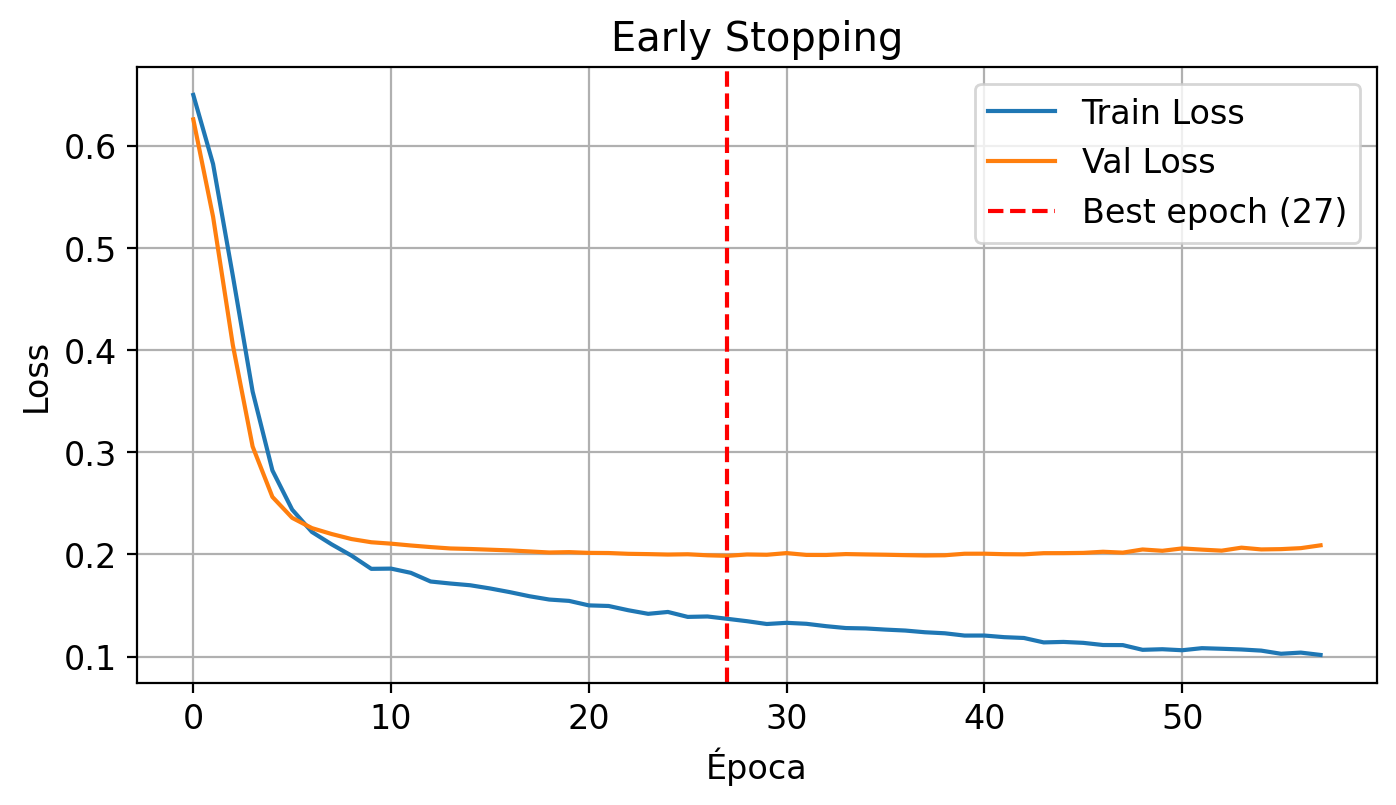


Prestaciones en TEST con early stopping: AUC=0.9844, Acc=0.9450


In [60]:
### Ejercicio 3: Early Stopping

import copy

class MLP_early_stopping(MLP):

    def __init__(self, dimx, n_hidden1, n_hidden2, num_train_data,
                 epochs=100, lr=0.001, batch_size=50, print_every=20, patience=20):

        super().__init__(dimx, n_hidden1, n_hidden2)
        self.lr = lr
        self.optim = optim.Adam(self.parameters(), self.lr)
        self.epochs = epochs
        self.print_every = print_every
        self.criterion = nn.BCELoss()
        self.batch_size = batch_size
        self.num_train = num_train_data
        self.num_batchs = np.floor(self.num_train / self.batch_size)
        self.patience = patience

        self.train_loss_hist = []
        self.val_loss_hist = []
        self.best_val_loss = float('inf')
        self.best_epoch = 0
        self.best_state = None

    def fit(self, x_train, y_train, x_val, y_val):

        x_val_t = torch.tensor(x_val) if not isinstance(x_val, torch.Tensor) else x_val
        y_val_t = torch.tensor(y_val) if not isinstance(y_val, torch.Tensor) else y_val
        x_train_t = torch.tensor(x_train) if not isinstance(x_train, torch.Tensor) else x_train
        y_train_t = torch.tensor(y_train) if not isinstance(y_train, torch.Tensor) else y_train

        epochs_no_improve = 0

        for e in range(int(self.epochs)):
            # --- Entrenamiento ---
            self.train()
            idx = np.random.permutation(self.num_train)
            running_loss = 0.

            for i in range(int(self.num_batchs)):
                self.optim.zero_grad()
                idx_batch = idx[i * self.batch_size:(i + 1) * self.batch_size]
                out = self.forward(x_train_t[idx_batch, :])
                loss = self.criterion(out, y_train_t[idx_batch].view(self.batch_size, 1))
                running_loss += loss.item()
                loss.backward()
                self.optim.step()

            self.train_loss_hist.append(running_loss / self.num_batchs)

            # --- Validación ---
            self.eval()
            with torch.no_grad():
                out_val = self.forward(x_val_t)
                val_loss = self.criterion(out_val, y_val_t.view(-1, 1)).item()
            self.val_loss_hist.append(val_loss)

            # --- Early stopping check ---
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_epoch = e
                self.best_state = copy.deepcopy(self.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if e % self.print_every == 0:
                print(f"Epoch {e:4d} | Train Loss={self.train_loss_hist[-1]:.4f} | Val Loss={val_loss:.4f} | Best={self.best_val_loss:.4f} (ep {self.best_epoch})")

            if epochs_no_improve >= self.patience:
                print(f"\nEarly stopping en época {e}. Mejor época: {self.best_epoch} con Val Loss={self.best_val_loss:.4f}")
                break

        # Restaurar los mejores pesos
        self.load_state_dict(self.best_state)
        print(f"Modelo restaurado a los pesos de la época {self.best_epoch}")

# Entrenar con early stopping
X_tr, X_val, y_tr, y_val = tts(X_train, y_train, test_size=0.2, random_state=42)

mlp_es = MLP_early_stopping(
    X_tr.shape[1], 20, 10, num_train_data=X_tr.shape[0],
    epochs=1000, lr=0.001, batch_size=100, print_every=25, patience=30
)
mlp_es.fit(X_tr, y_tr, X_val, y_val)

# Visualizar
plt.figure(figsize=(8, 4))
plt.plot(mlp_es.train_loss_hist, label='Train Loss')
plt.plot(mlp_es.val_loss_hist, label='Val Loss')
plt.axvline(x=mlp_es.best_epoch, color='r', linestyle='--', label=f'Best epoch ({mlp_es.best_epoch})')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Early Stopping')
plt.legend()
plt.grid(True)
plt.show()

# Evaluar en test
out_test_es = mlp_es.forward(torch.tensor(X_test)).detach().numpy().reshape(-1)
auc_test = metrics.roc_auc_score(y_test, out_test_es)
acc_test = metrics.accuracy_score(y_test, (out_test_es > 0.5).astype(int))
print(f"\nPrestaciones en TEST con early stopping: AUC={auc_test:.4f}, Acc={acc_test:.4f}")